# Análisis estadístico por CCAA — Ejecución Presupuestaria (TFM)

**Objetivo:** dejar claro, *comunidad por comunidad*, qué supuestos estadísticos cumplen
las variables clave del feature store, para **justificar la elección de modelos**.

Para cada CCAA y cada variable estudiamos:

| Bloque | Qué responde | Herramientas |
|--------|--------------|--------------|
| **1. Descriptivos** | ¿Cómo es la variable? Centro y dispersión | media, mediana, desv. típica, percentiles, CV |
| **2. Normalidad** | ¿Sigue una campana de Gauss? → ¿pruebas *paramétricas* o *no paramétricas*? | Histograma + KDE, Q-Q plot, Shapiro-Wilk, D'Agostino-Pearson, Kolmogórov-Smirnov, asimetría y curtosis |
| **3. Homocedasticidad** | ¿La varianza de los errores es constante en todos los niveles? | Gráfico de residuos, *scale-location*, test de Levene (entre grupos), test de Breusch-Pagan (en regresión) |
| **4. Tendencias** | ¿Cómo evoluciona en el tiempo? | Series temporales etiquetadas por CCAA |

> **Cómo leer las conclusiones**
> - **Normalidad** — si *p* < 0.05 se **rechaza** la normalidad ⇒ usar **pruebas no paramétricas**
>   (Mann-Whitney, Kruskal-Wallis, Spearman) y modelos robustos a distribuciones no normales
>   (Random Forest, XGBoost). Si *p* ≥ 0.05 ⇒ caben **pruebas paramétricas** (t-Student, ANOVA, Pearson, OLS).
> - **Homocedasticidad** — si *p* < 0.05 hay **heterocedasticidad** (varianza no constante) ⇒ la
>   regresión lineal ordinaria (OLS) es ineficiente; preferimos modelos de árboles o errores robustos.

**Requisito:** haber generado el feature store (`data_lake/03_features/<ccaa>/features/`).
Este notebook **no** necesita la base de datos SQLite; lee directamente los Parquet.

## 1 · Configuración e imports

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

# Raíz del proyecto (este notebook vive en notebooks/)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FEATURES_DIR = ROOT / "data_lake" / "03_features"
REPORTS_DIR = ROOT / "reports" / "estadistica_ccaa"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# CCAA con fase OBR (aptas para el análisis completo de supuestos)
CCAA_OBR = [
    "aragon", "asturias", "canarias", "cataluna", "madrid", "pais-vasco",
    "illes-balears", "castilla-la-mancha", "castilla-y-leon", "nacional",
]

CCAA_NAMES = {
    "aragon": "Aragón", "asturias": "Asturias", "canarias": "Canarias",
    "cataluna": "Cataluña", "madrid": "Madrid", "pais-vasco": "País Vasco",
    "illes-balears": "Illes Balears", "castilla-la-mancha": "C.-La Mancha",
    "castilla-y-leon": "Castilla y León", "nacional": "AGE (nacional)",
    "murcia": "Murcia", "galicia": "Galicia",
    "comunidad-valenciana": "C. Valenciana",
}
CAPITULO_NAMES = {
    1: "1·Personal", 2: "2·Bienes/Serv.", 3: "3·G.Financ.", 4: "4·Transf.corr.",
    5: "5·Conting.", 6: "6·Inversiones", 7: "7·Transf.cap.",
    8: "8·Act.financ.", 9: "9·Pas.financ.",
}

def ccaa_label(s):  # slug -> nombre legible
    return CCAA_NAMES.get(s, s)

def cap_label(c):
    try:
        return CAPITULO_NAMES.get(int(c), f"Cap.{int(c)}")
    except (TypeError, ValueError):
        return "?"

ALPHA = 0.05            # nivel de significación
MAX_IMPORTE = 1e11      # umbral de saneo (|importe| físicamente imposible)
print("ROOT:", ROOT)
print("Feature store:", FEATURES_DIR)

ROOT: C:\Users\usuario\Documents\Master\Projects\Ejecucion_presupuestaria
Feature store: C:\Users\usuario\Documents\Master\Projects\Ejecucion_presupuestaria\data_lake\03_features


## 2 · Carga del feature store y saneo

Cargamos los Parquet de cada CCAA con fase OBR y eliminamos filas con importes
imposibles (`|importe| > 1×10¹¹ €`, errores de parseo conocidos en Avilés/Asturias),
el **mismo umbral** que usa `scripts/eda.py`. Trabajar sobre datos limpios es
condición previa a cualquier contraste estadístico.

In [2]:
IMPORTE_COLS = ["PRE", "OBR", "CRE", "PAG"]

import re

def load_ccaa(slug: str) -> pd.DataFrame:
    """Carga el feature store de una CCAA leyendo los Parquet fichero a fichero.

    Se evita ds.dataset(...).to_table(), que en algunas versiones de pyarrow
    (p. ej. la incluida en Anaconda) lanza OSError al unificar el esquema hive.
    Es tolerante a ficheros ilegibles (los omite con aviso) y reconstruye la
    columna 'anio' desde la ruta de partición (carpeta anio=YYYY).
    """
    feat_dir = FEATURES_DIR / slug / "features"
    files = sorted(feat_dir.rglob("*.parquet")) if feat_dir.exists() else []
    if not files:
        return pd.DataFrame()
    parts = []
    for f in files:
        try:
            d = pd.read_parquet(f)            # motor pyarrow/fastparquet por defecto
        except Exception as exc:
            print(f"  [WARN] Parquet ilegible omitido: {f.name} ({slug}) -> {type(exc).__name__}")
            continue
        if "anio" not in d.columns:
            m = re.search(r"anio=(\d+)", str(f))
            if m:
                d["anio"] = int(m.group(1))
        parts.append(d)
    if not parts:
        return pd.DataFrame()
    df = pd.concat(parts, ignore_index=True)
    df["ccaa_slug"] = slug
    return df

frames, n_antes, n_bad = [], 0, 0
for slug in CCAA_OBR:
    df = load_ccaa(slug)
    if df.empty:
        print(f"  [SKIP] sin feature store: {slug}")
        continue
    n_antes += len(df)
    mask_bad = pd.Series(False, index=df.index)
    for c in [c for c in IMPORTE_COLS if c in df.columns]:
        mask_bad |= df[c].abs() > MAX_IMPORTE
    n_bad += int(mask_bad.sum())
    frames.append(df.loc[~mask_bad].copy())

data = pd.concat(frames, ignore_index=True)
data["nombre"] = data["ccaa_slug"].map(ccaa_label)
print(f"Filas: {n_antes:,} -> {len(data):,} tras eliminar {n_bad:,} corruptas")
print("CCAA cargadas:", ", ".join(sorted(data['nombre'].unique())))
data[["ccaa_slug", "anio", "capitulo_id", "PRE", "CRE", "OBR", "ejecutado_pct", "brecha_pct"]].head()

Filas: 13,545 -> 13,311 tras eliminar 234 corruptas
CCAA cargadas: AGE (nacional), Aragón, Asturias, C.-La Mancha, Canarias, Castilla y León, Cataluña, Illes Balears, Madrid, País Vasco


,ccaa_slug,anio,capitulo_id,PRE,CRE,OBR,ejecutado_pct,brecha_pct
0,aragon,2012,1.0,15204000.00,15204000.00,14540871.84,0.956385,0.043615
1,aragon,2012,1.0,2065390.02,2065390.02,1790124.18,0.866725,0.133275
2,aragon,2012,1.0,17696641.80,17696641.80,16179291.54,0.914258,0.085742
3,aragon,2012,2.0,45009600.00,45009600.00,41899189.86,0.930895,0.069105
4,aragon,2012,2.0,435775.98,375429.00,268137.30,0.714216,0.384690


In [3]:
# Variables clave a analizar. Para los importes (OBR/PRE/CRE) usamos escala log1p
# porque abarcan varios órdenes de magnitud; los ratios se analizan en escala original.
VARIABLES = {
    "OBR":           {"label": "Obligaciones reconocidas (OBR, €)", "log": True,  "clip": None},
    "PRE":           {"label": "Crédito inicial (PRE, €)",          "log": True,  "clip": None},
    "ejecutado_pct": {"label": "Tasa de ejecución OBR/CRE",         "log": False, "clip": (0, 2)},
    "brecha_pct":    {"label": "Brecha (PRE−OBR)/PRE",              "log": False, "clip": (-2, 2)},
}

def get_series(df: pd.DataFrame, var: str) -> pd.Series:
    'Serie limpia y transformada lista para analizar.'
    cfg = VARIABLES[var]
    s = pd.to_numeric(df[var], errors="coerce").dropna()
    s = s[np.isfinite(s)]
    if cfg["log"]:
        s = s[s > 0]
        s = np.log1p(s)
    elif cfg["clip"]:
        s = s.clip(*cfg["clip"])
    return s

CCAA_ORDER = [s for s in CCAA_OBR if s in data["ccaa_slug"].unique()]
print("Variables:", list(VARIABLES))

Variables: ['OBR', 'PRE', 'ejecutado_pct', 'brecha_pct']


## 3 · Estadísticos descriptivos por CCAA

Para cada CCAA y variable: **media**, **mediana**, **desviación típica**, percentiles y
**coeficiente de variación** (CV = σ/μ, dispersión relativa). Una gran diferencia
media↔mediana ya anticipa **asimetría** (no normalidad).

In [4]:
def tabla_descriptiva(var: str) -> pd.DataFrame:
    rows = []
    for slug in CCAA_ORDER:
        s = get_series(data[data["ccaa_slug"] == slug], var)
        if len(s) < 5:
            continue
        mean = s.mean()
        rows.append({
            "CCAA": ccaa_label(slug),
            "n": len(s),
            "media": mean,
            "mediana": s.median(),
            "desv_típica": s.std(ddof=1),
            "CV": (s.std(ddof=1) / mean) if mean != 0 else np.nan,
            "p25": s.quantile(0.25),
            "p75": s.quantile(0.75),
            "mín": s.min(),
            "máx": s.max(),
        })
    out = pd.DataFrame(rows)
    return out.round(4)

for var, cfg in VARIABLES.items():
    suf = " [log1p]" if cfg["log"] else (f" [clip {cfg['clip']}]" if cfg["clip"] else "")
    print(f"\n=== {cfg['label']}{suf} ===")
    display(tabla_descriptiva(var))


=== Obligaciones reconocidas (OBR, €) [log1p] ===


,CCAA,n,media,mediana,desv_típica,CV,p25,p75,mín,máx
0,Aragón,6083,15.8316,15.9755,2.8317,0.1789,14.3223,17.4450,2.6012,25.2373
1,Asturias,63,17.0342,17.4575,2.0321,0.1193,14.8199,19.0043,13.3334,19.3979
2,Canarias,771,23.7924,23.7394,0.9071,0.0381,23.2119,24.5101,18.7082,25.3232
3,Cataluña,122,20.3724,20.2021,2.2442,0.1102,19.0607,21.4407,15.4099,24.9557
4,Madrid,75,19.4258,19.6759,2.4006,0.1236,18.3328,21.1320,13.5055,22.5884
5,País Vasco,70,21.8921,21.8357,0.8108,0.0370,21.3459,22.5666,20.3663,23.3083
6,Illes Balears,21,22.3655,22.4487,0.3821,0.0171,22.1624,22.5969,21.3673,22.9278
7,C.-La Mancha,29,21.7057,21.6022,1.1785,0.0543,20.7917,22.8398,19.6966,23.5210
8,Castilla y León,72,20.7088,21.0136,1.8251,0.0881,19.8320,22.4512,16.8156,22.8792
9,AGE (nacional),77,20.8199,20.8303,1.4210,0.0683,19.5102,22.5397,18.3436,22.9336



=== Crédito inicial (PRE, €) [log1p] ===


,CCAA,n,media,mediana,desv_típica,CV,p25,p75,mín,máx
0,Aragón,7941,16.1791,16.2265,2.7282,0.1686,14.5659,17.7817,2.3026,25.3183
1,Asturias,111,17.2017,17.7261,2.1082,0.1226,15.4665,19.0284,13.0170,20.1489
2,Canarias,771,23.3298,23.4522,1.2751,0.0547,22.7829,24.2665,18.1200,25.3067
3,Cataluña,132,20.8730,20.9081,2.3582,0.1130,19.4951,22.3675,15.8619,25.1488
4,Madrid,93,20.5292,20.7496,1.9879,0.0968,19.6461,22.2418,13.7402,23.6735
5,País Vasco,84,22.0895,22.5717,1.7830,0.0807,21.9001,23.1401,17.0872,24.2463
6,Illes Balears,23,22.4539,22.3069,0.7311,0.0326,22.1620,22.6453,21.0143,24.3398
7,C.-La Mancha,14,23.0787,23.1011,0.4193,0.0182,22.9807,23.3396,21.9082,23.6321
8,Castilla y León,73,20.8017,21.0840,1.7583,0.0845,19.9907,22.4724,17.0421,22.8387
9,AGE (nacional),3802,16.2500,16.4272,2.9199,0.1797,14.5651,18.0588,5.7838,25.1824



=== Tasa de ejecución OBR/CRE [clip (0, 2)] ===


,CCAA,n,media,mediana,desv_típica,CV,p25,p75,mín,máx
0,Aragón,6086,0.8616,0.9308,0.2966,0.3443,0.7832,0.9945,0.0000,2.0000
1,Asturias,63,0.6322,0.7354,0.3399,0.5376,0.3731,0.9296,0.0243,1.1045
2,Canarias,684,1.8540,1.9799,0.2180,0.1176,1.7568,2.0000,0.5384,2.0000
3,Cataluña,76,0.9412,0.9860,0.4126,0.4384,0.7344,1.0979,0.0609,2.0000
4,Madrid,78,0.4326,0.3627,0.4055,0.9372,0.0547,0.7228,0.0000,1.5026
5,País Vasco,80,0.4192,0.4490,0.1881,0.4487,0.3596,0.5339,0.0000,0.7316
6,Illes Balears,21,0.9698,0.9795,0.0660,0.0681,0.9437,1.0146,0.7658,1.0657
7,Castilla y León,72,0.8523,0.9001,0.2689,0.3155,0.7849,0.9940,0.1752,2.0000



=== Brecha (PRE−OBR)/PRE [clip (-2, 2)] ===


,CCAA,n,media,mediana,desv_típica,CV,p25,p75,mín,máx
0,Aragón,5929,0.2314,0.2564,0.6638,2.8683,0.0264,0.6956,-2.0000,1.0000
1,Asturias,63,0.4000,0.5205,0.4533,1.1333,0.4209,0.5641,-2.0000,0.9075
2,Canarias,764,-0.4338,-0.2452,0.6153,-1.4185,-0.5703,-0.0897,-2.0000,0.9655
3,Cataluña,132,0.0528,0.0129,0.7332,13.8996,-0.1644,0.4871,-2.0000,1.0000
4,Madrid,77,0.5235,0.5028,0.4292,0.8199,0.2656,0.9167,-1.1691,1.0000
5,País Vasco,80,0.6384,0.6290,0.1948,0.3051,0.5322,0.7125,-0.2264,1.0000
6,Illes Balears,21,-0.0944,-0.0896,0.2251,-2.3834,-0.1637,-0.0566,-0.5179,0.6620
7,C.-La Mancha,13,0.1549,0.3146,0.3002,1.9388,0.1051,0.3161,-0.4650,0.4222
8,Castilla y León,72,0.0595,0.0553,0.2716,4.5645,-0.0397,0.1981,-1.5377,0.5792
9,AGE (nacional),47,0.1916,0.9356,1.2681,6.6195,-0.2704,0.9673,-2.0000,0.9814


### 3.1 · Comparación visual de media · mediana · desviación

Barras etiquetadas con el valor exacto. Donde **media ≫ mediana** la distribución
está sesgada a la derecha (colas pesadas → típico de importes presupuestarios).

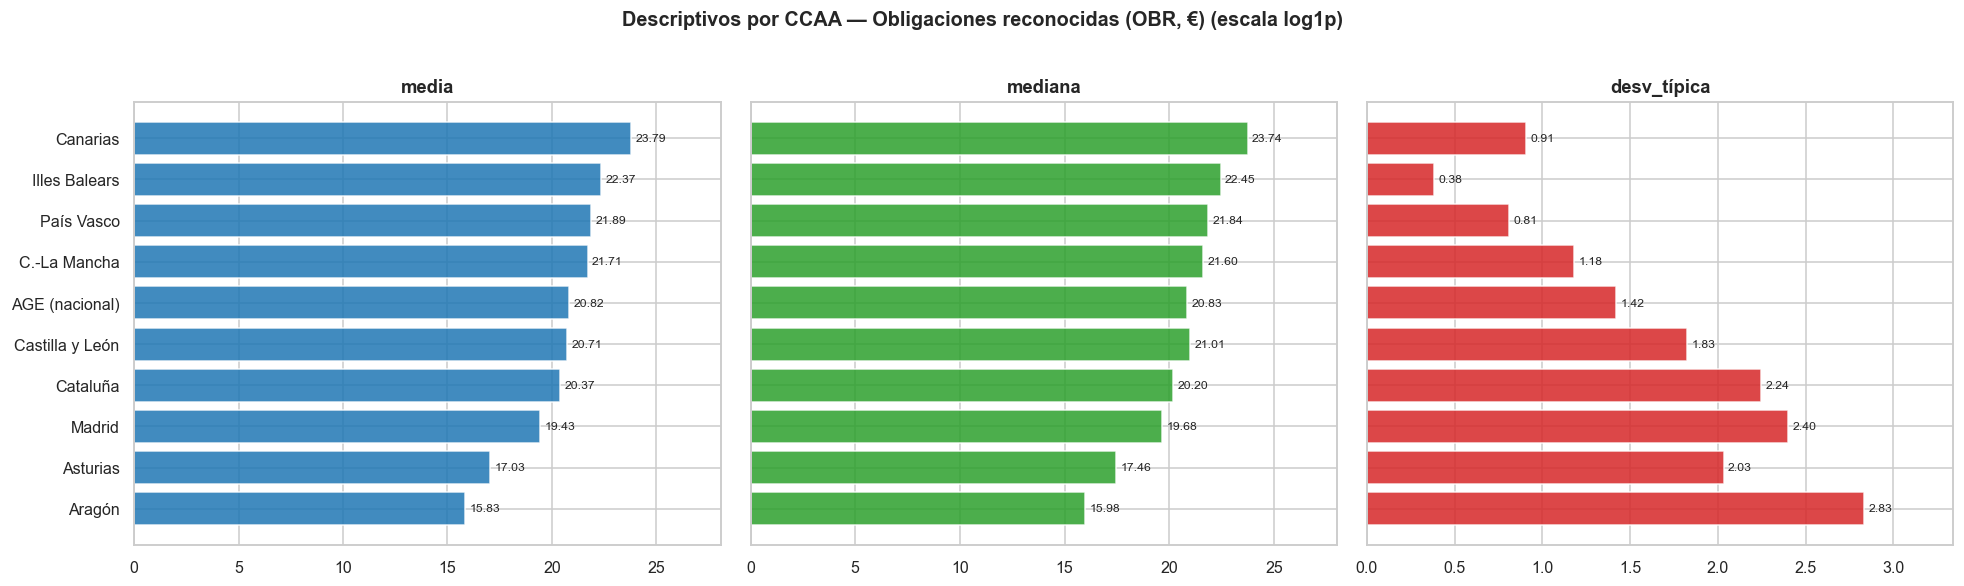

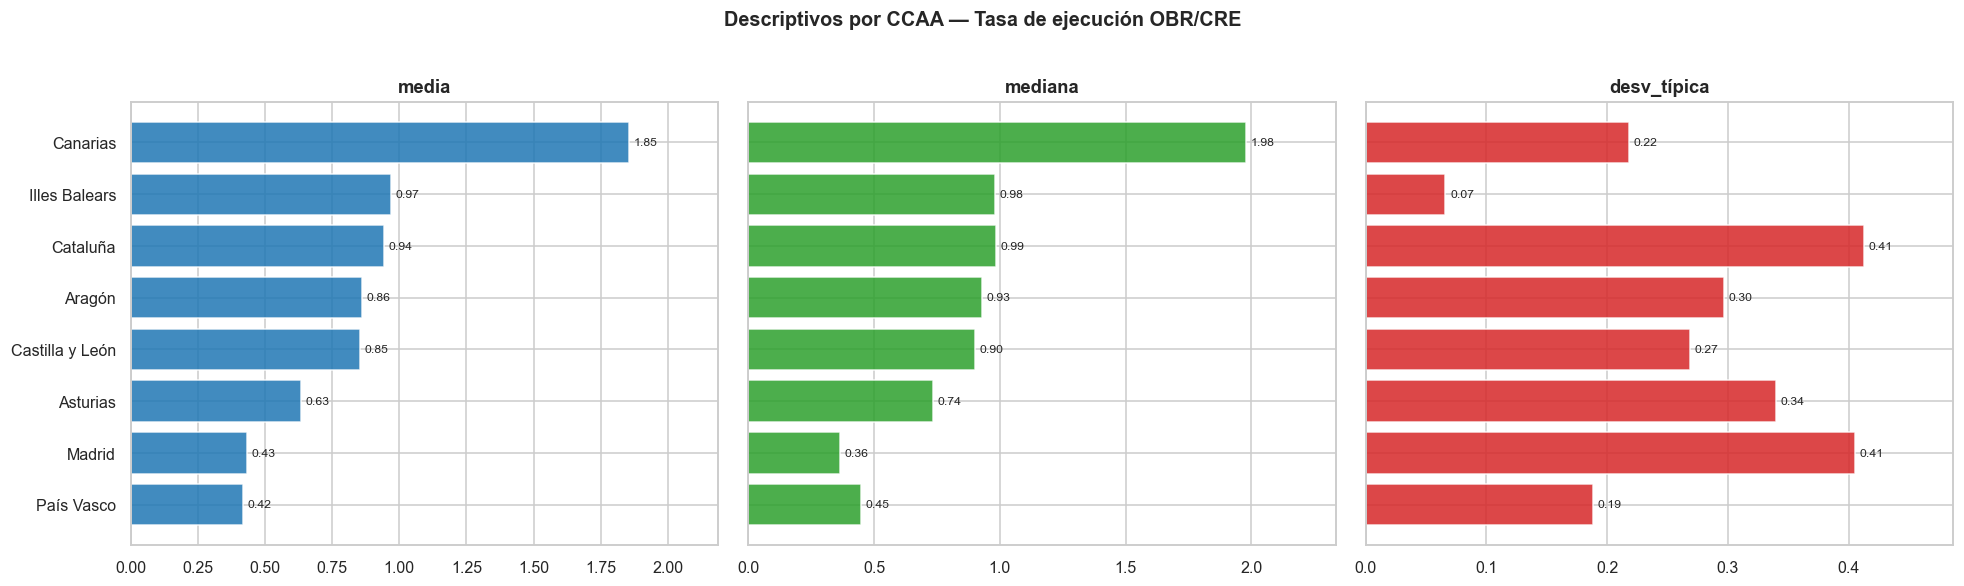

In [5]:
def plot_descriptivos(var: str):
    cfg = VARIABLES[var]
    tab = tabla_descriptiva(var).set_index("CCAA")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
    metricas = [("media", "#1f77b4"), ("mediana", "#2ca02c"), ("desv_típica", "#d62728")]
    for ax, (m, color) in zip(axes, metricas):
        vals = tab[m].sort_values()
        bars = ax.barh(vals.index, vals.values, color=color, alpha=0.85)
        ax.set_title(m, fontsize=12, weight="bold")
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
        ax.margins(x=0.18)
    suf = " (escala log1p)" if cfg["log"] else ""
    fig.suptitle(f"Descriptivos por CCAA — {cfg['label']}{suf}", y=1.02, fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / f"descriptivos_{var}.png", bbox_inches="tight", dpi=110)
    fig.savefig(REPORTS_DIR / f"comparacion_mediana_desv_{var}.png", dpi=300)
    plt.show()

plot_descriptivos("OBR")
plot_descriptivos("ejecutado_pct")

## 4 · Normalidad

**¿Por qué importa?** Las pruebas *paramétricas* (t-Student, ANOVA, regresión OLS, Pearson)
asumen que los datos (o los residuos) siguen una **distribución normal**. Si no se cumple,
sus conclusiones pierden validez y conviene recurrir a **pruebas no paramétricas**.

Combinamos tres evidencias:

1. **Histograma + KDE** vs. la normal teórica → inspección visual de la forma.
2. **Q-Q plot** → si los puntos siguen la diagonal, hay normalidad; las desviaciones en
   los extremos delatan **colas pesadas** o asimetría.
3. **Tests formales** — Shapiro-Wilk (potente, n≤5000), D'Agostino-Pearson (asimetría+curtosis)
   y Kolmogórov-Smirnov. H₀ = "los datos son normales".

### 4.1 · Histograma + KDE por CCAA (con la normal teórica superpuesta)

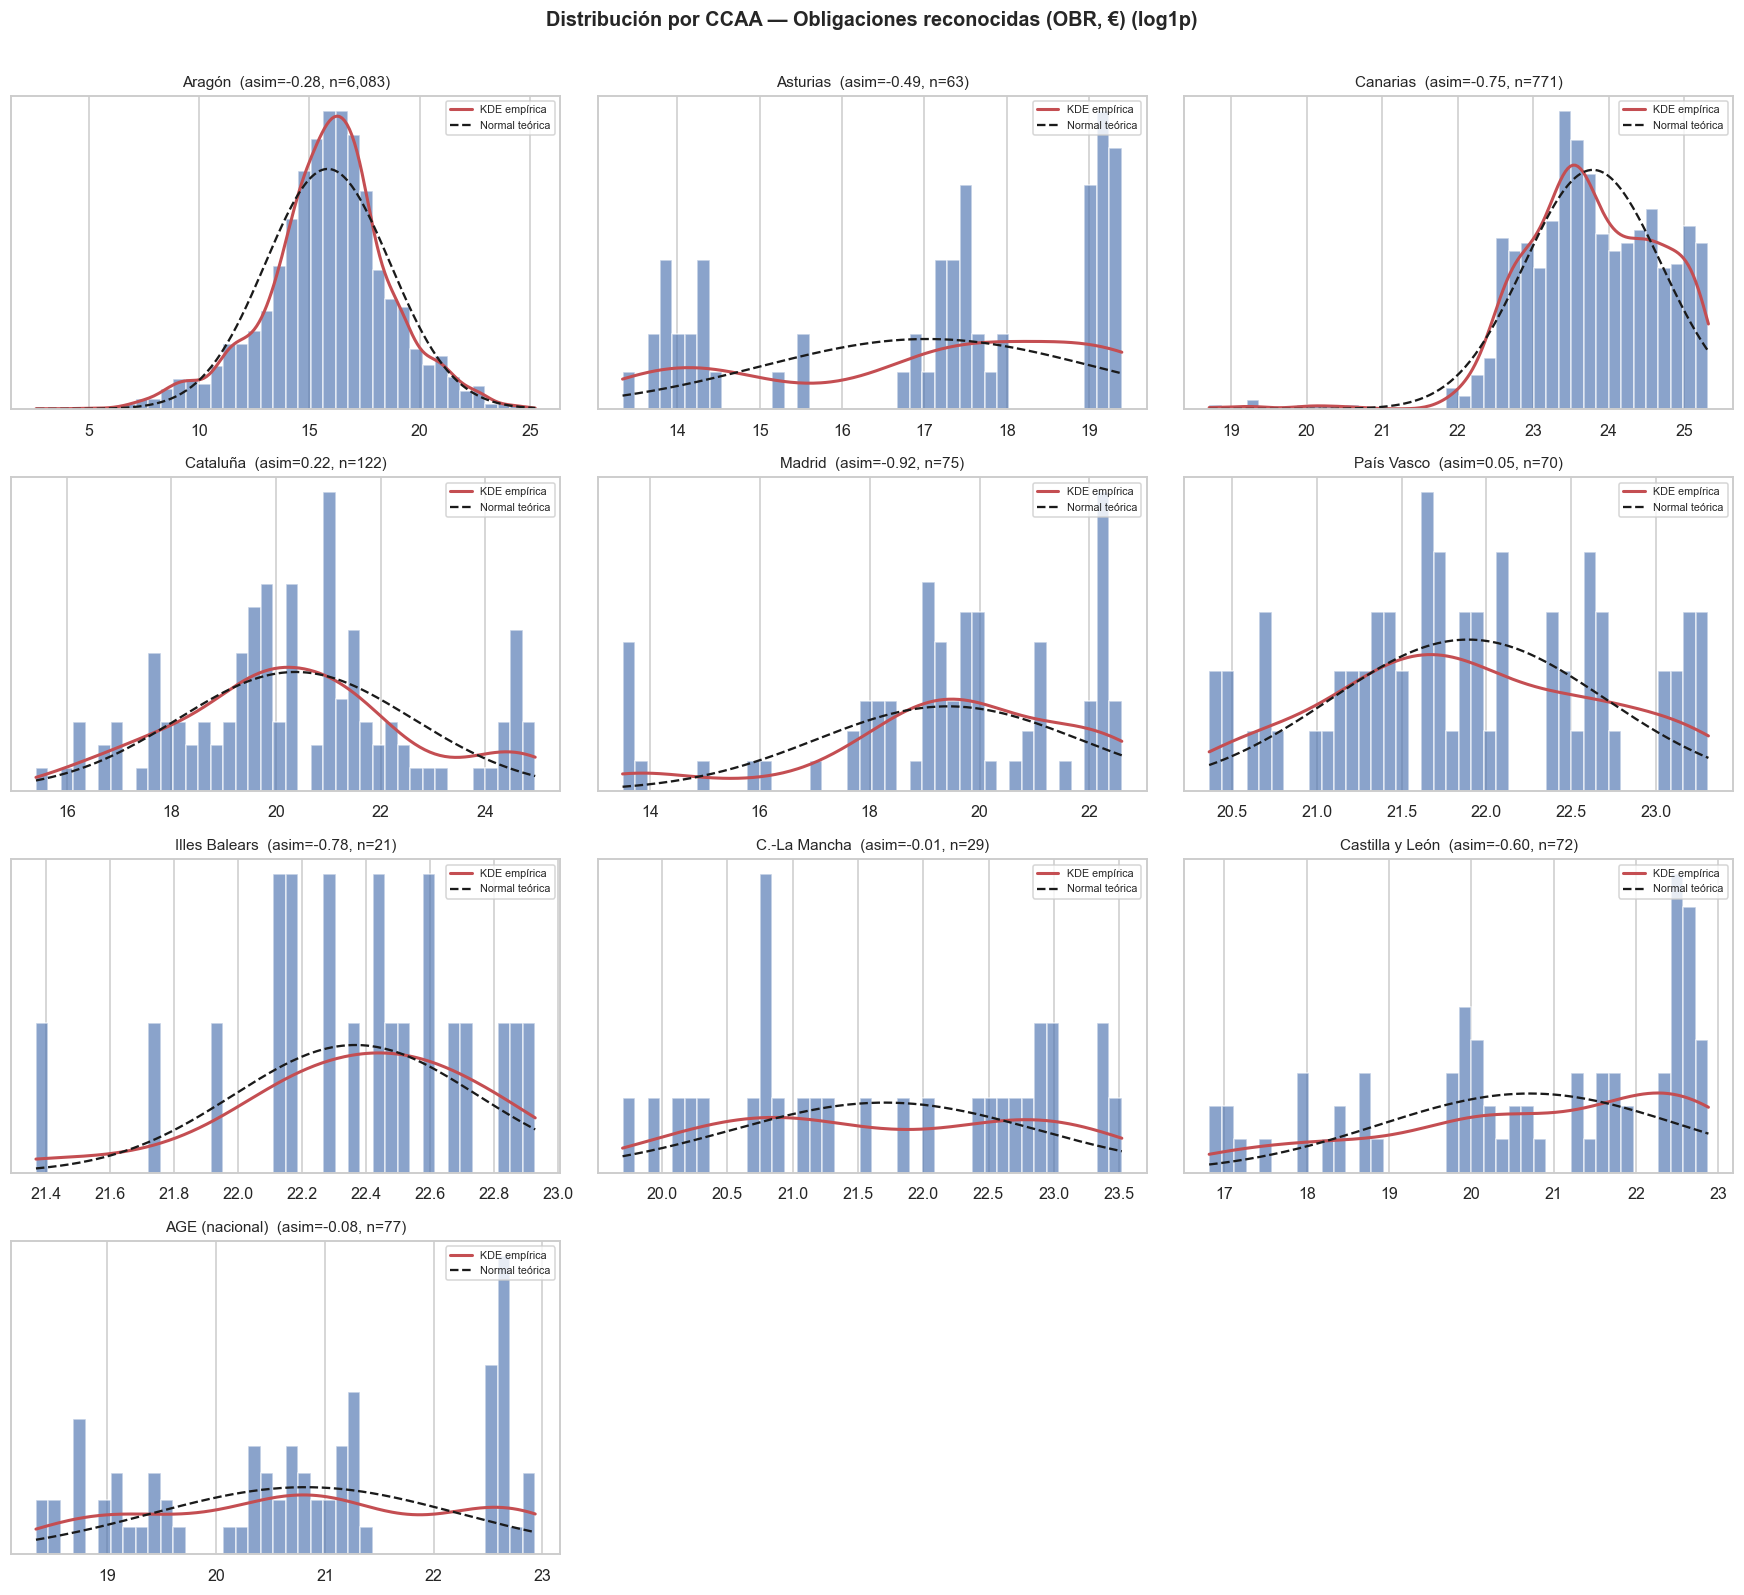

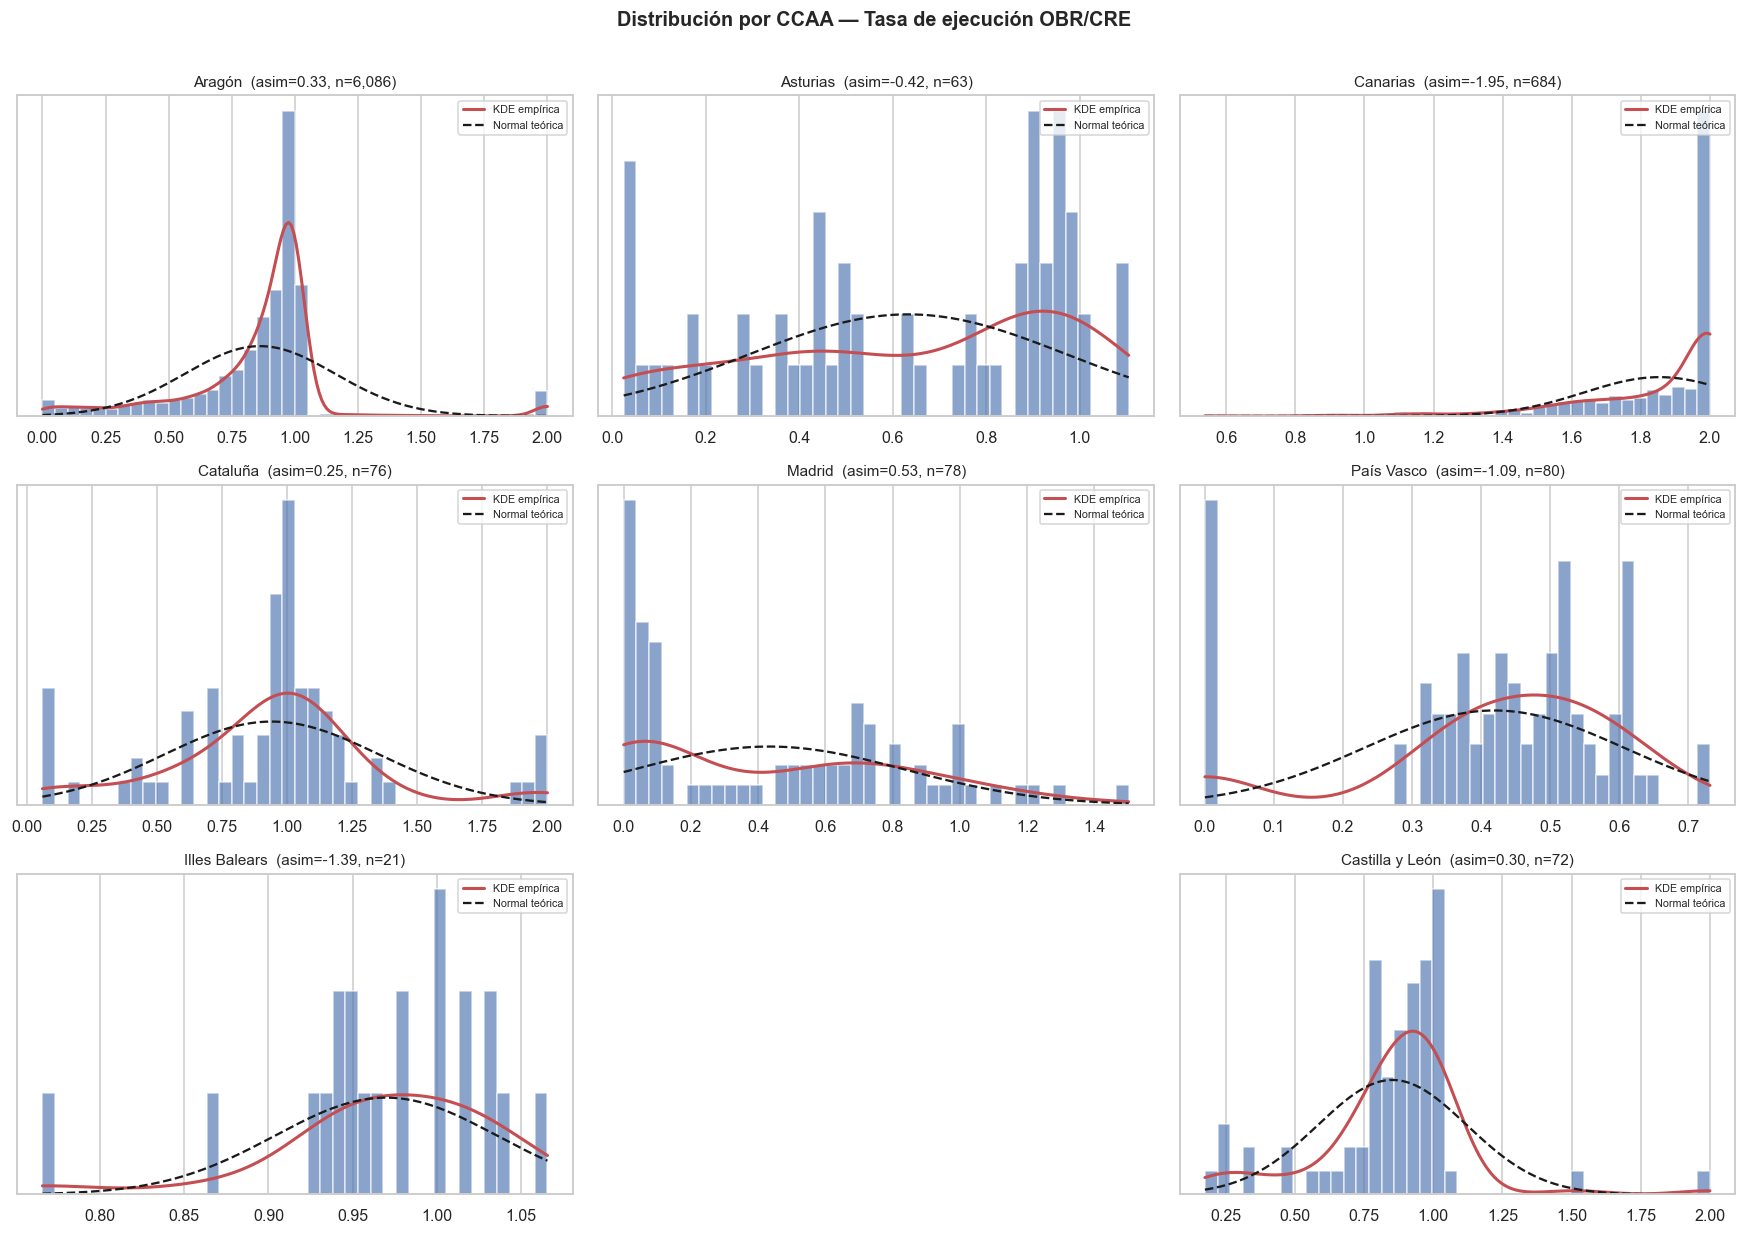

In [6]:
def grid_histogramas(var: str):
    cfg = VARIABLES[var]
    n = len(CCAA_ORDER)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, slug in zip(axes, CCAA_ORDER):
        s = get_series(data[data["ccaa_slug"] == slug], var)
        if len(s) < 10:
            ax.set_visible(False)
            continue
        ax.hist(s, bins=40, density=True, color="#4c72b0", alpha=0.65, edgecolor="white")
        # curva KDE empírica
        try:
            kde = stats.gaussian_kde(s)
            xs = np.linspace(s.min(), s.max(), 200)
            ax.plot(xs, kde(xs), color="#c44e52", lw=2, label="KDE empírica")
        except Exception:
            pass
        # normal teórica con misma media y sigma
        xs = np.linspace(s.min(), s.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, s.mean(), s.std()), "k--", lw=1.5, label="Normal teórica")
        sk = stats.skew(s)
        ax.set_title(f"{ccaa_label(slug)}  (asim={sk:.2f}, n={len(s):,})", fontsize=10)
        ax.set_yticks([])
        ax.legend(fontsize=7, loc="upper right")
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(f"Distribución por CCAA — {cfg['label']}"
                 + (" (log1p)" if cfg["log"] else ""), y=1.005, fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / f"hist_{var}.png", bbox_inches="tight", dpi=110)
    plt.show()

grid_histogramas("OBR")
grid_histogramas("ejecutado_pct")

### 4.2 · Q-Q plots por CCAA

Cada punto compara un cuantil empírico con el de una normal. **Sobre la recta roja ⇒ normal.**
Una curva en "S" indica colas pesadas; una curva cóncava/convexa indica asimetría.

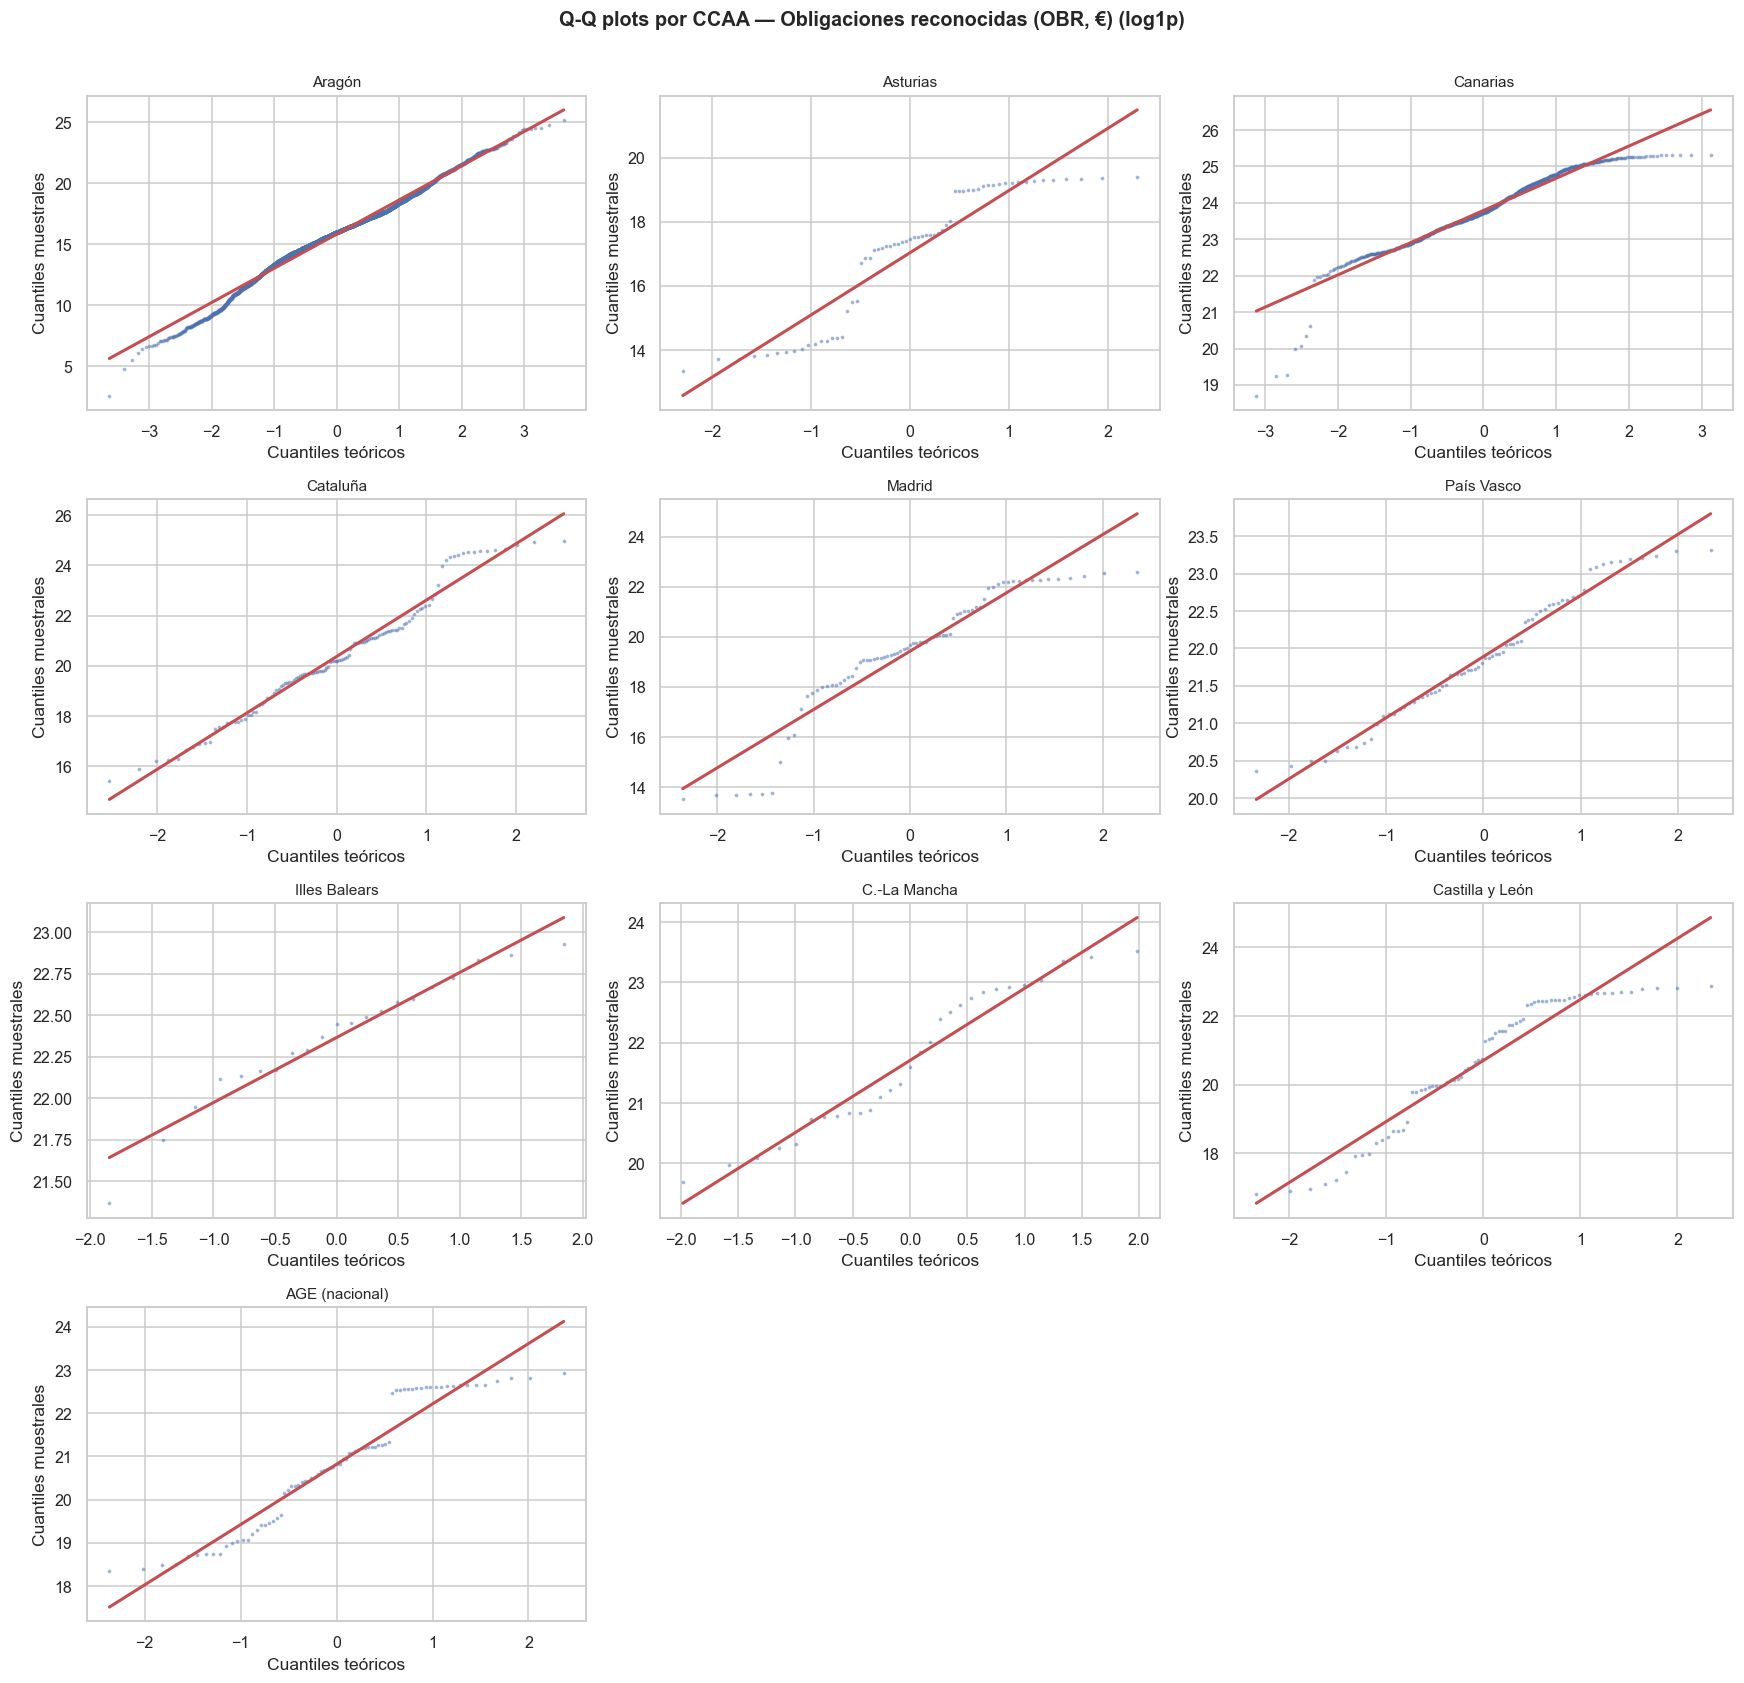

In [7]:
def grid_qqplots(var: str):
    cfg = VARIABLES[var]
    n = len(CCAA_ORDER)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, slug in zip(axes, CCAA_ORDER):
        s = get_series(data[data["ccaa_slug"] == slug], var)
        if len(s) < 10:
            ax.set_visible(False)
            continue
        samp = s.sample(min(5000, len(s)), random_state=42)
        stats.probplot(samp, dist="norm", plot=ax)
        ax.get_lines()[0].set(marker=".", markersize=3, alpha=0.4, color="#4c72b0")
        ax.get_lines()[1].set(color="#c44e52", lw=2)
        ax.set_title(ccaa_label(slug), fontsize=10)
        ax.set_xlabel("Cuantiles teóricos"); ax.set_ylabel("Cuantiles muestrales")
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(f"Q-Q plots por CCAA — {cfg['label']}"
                 + (" (log1p)" if cfg["log"] else ""), y=1.005, fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / f"qq_{var}.png", bbox_inches="tight", dpi=110)
    plt.show()

grid_qqplots("OBR")

### 4.3 · Tests formales de normalidad

Para cada CCAA: **Shapiro-Wilk**, **D'Agostino-Pearson** y **Kolmogórov-Smirnov**, más
asimetría y curtosis. Si *p* < 0.05 se **rechaza** la normalidad. La columna **Recomendación**
traduce el resultado a la práctica (paramétrica vs no paramétrica).

In [8]:
def _fmt_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "—"
    return f"{p:.2e}" if p < 1e-4 else f"{p:.4f}"

def tabla_normalidad(var: str) -> pd.DataFrame:
    rows = []
    for slug in CCAA_ORDER:
        s = get_series(data[data["ccaa_slug"] == slug], var)
        if len(s) < 20:
            continue
        samp = s.sample(min(5000, len(s)), random_state=42)
        try:
            W, pW = stats.shapiro(samp)
        except Exception:
            W, pW = np.nan, np.nan
        try:
            K2, pK2 = stats.normaltest(s)
        except Exception:
            K2, pK2 = np.nan, np.nan
        sd = s.std(ddof=0)
        ks, pks = stats.kstest((s - s.mean()) / sd, "norm") if sd > 0 else (np.nan, np.nan)
        # consenso: normal solo si NINGÚN test rechaza
        ps = [p for p in (pW, pK2, pks) if not np.isnan(p)]
        es_normal = bool(ps) and all(p >= ALPHA for p in ps)
        rows.append({
            "CCAA": ccaa_label(slug), "n": len(s),
            "Shapiro W": round(W, 4), "p(SW)": _fmt_p(pW),
            "D'Agostino K²": round(K2, 1), "p(K²)": _fmt_p(pK2),
            "p(KS)": _fmt_p(pks),
            "Asimetría": round(float(stats.skew(s)), 3),
            "Curtosis": round(float(stats.kurtosis(s)), 3),
            "¿Normal?": "Sí" if es_normal else "No",
            "Recomendación": "Paramétrica" if es_normal else "No paramétrica",
        })
    return pd.DataFrame(rows)

for var, cfg in VARIABLES.items():
    print(f"\n=== Normalidad — {cfg['label']}" + (" (log1p)" if cfg['log'] else "") + " ===")
    display(tabla_normalidad(var))


=== Normalidad — Obligaciones reconocidas (OBR, €) (log1p) ===


,CCAA,n,Shapiro W,p(SW),D'Agostino K²,p(K²),p(KS),Asimetría,Curtosis,¿Normal?,Recomendación
0,Aragón,6083,0.9870,4.24e-21,151.8,1.11e-33,6.94e-13,-0.276,0.741,No,No paramétrica
1,Asturias,63,0.8616,4.35e-06,19.9,4.86e-05,0.0553,-0.487,-1.205,No,No paramétrica
2,Canarias,771,0.9471,5.55e-16,110.3,1.09e-24,0.0781,-0.752,2.554,No,No paramétrica
3,Cataluña,122,0.9712,0.0102,1.4,0.4843,0.4917,0.221,-0.322,No,No paramétrica
4,Madrid,75,0.8996,2.07e-05,10.9,0.0043,0.1080,-0.916,0.467,No,No paramétrica
5,País Vasco,70,0.9670,0.0619,5.1,0.0781,0.8628,0.045,-0.876,Sí,Paramétrica
6,Illes Balears,21,0.9535,0.3958,4.1,0.1296,0.9284,-0.777,0.496,Sí,Paramétrica
7,C.-La Mancha,29,0.9308,0.0577,9.3,0.0097,0.5629,-0.014,-1.365,No,No paramétrica
8,Castilla y León,72,0.9003,3.13e-05,8.3,0.0160,0.0747,-0.599,-0.801,No,No paramétrica
9,AGE (nacional),77,0.9187,0.0001,21.7,1.98e-05,0.0265,-0.078,-1.188,No,No paramétrica



=== Normalidad — Crédito inicial (PRE, €) (log1p) ===


,CCAA,n,Shapiro W,p(SW),D'Agostino K²,p(K²),p(KS),Asimetría,Curtosis,¿Normal?,Recomendación
0,Aragón,7941,0.9925,1.24e-15,107.9,3.71e-24,4.86e-07,-0.091,0.723,No,No paramétrica
1,Asturias,111,0.9339,3.41e-05,31.4,1.55e-07,0.0798,-0.279,-1.141,No,No paramétrica
2,Canarias,771,0.8834,1.27e-23,239.2,1.16e-52,2.02e-07,-1.529,3.575,No,No paramétrica
3,Cataluña,132,0.9760,0.0192,5.5,0.0654,0.5005,-0.040,-0.708,No,No paramétrica
4,Madrid,93,0.9285,7.53e-05,18.6,9.24e-05,0.3294,-1.014,1.361,No,No paramétrica
5,País Vasco,84,0.8011,2.74e-09,19.6,5.43e-05,1.39e-05,-1.295,0.584,No,No paramétrica
6,Illes Balears,23,0.8933,0.0185,6.7,0.0352,0.2914,0.896,1.190,No,No paramétrica
7,Castilla y León,73,0.8877,9.01e-06,7.8,0.0204,0.0875,-0.734,-0.588,No,No paramétrica
8,AGE (nacional),3802,0.9925,2.98e-13,46.0,1.04e-10,5.46e-06,-0.211,0.397,No,No paramétrica



=== Normalidad — Tasa de ejecución OBR/CRE ===


,CCAA,n,Shapiro W,p(SW),D'Agostino K²,p(K²),p(KS),Asimetría,Curtosis,¿Normal?,Recomendación
0,Aragón,6086,0.7735,5.85e-64,778.7,8.02e-170,0.00e+00,0.334,4.970,No,No paramétrica
1,Asturias,63,0.8993,8.52e-05,18.8,8.10e-05,0.0127,-0.422,-1.200,No,No paramétrica
2,Canarias,684,0.7208,3.09e-32,279.2,2.37e-61,1.46e-38,-1.953,4.488,No,No paramétrica
3,Cataluña,76,0.9109,5.57e-05,4.9,0.0863,0.0675,0.253,1.207,No,No paramétrica
4,Madrid,78,0.8843,3.60e-06,9.5,0.0088,0.0018,0.526,-0.867,No,No paramétrica
5,País Vasco,80,0.8654,5.51e-07,15.0,0.0006,0.0959,-1.088,0.580,No,No paramétrica
6,Illes Balears,21,0.8862,0.0191,13.4,0.0012,0.4914,-1.389,2.532,No,No paramétrica
7,Castilla y León,72,0.8312,1.32e-07,16.0,0.0003,0.0042,0.297,4.640,No,No paramétrica



=== Normalidad — Brecha (PRE−OBR)/PRE ===


,CCAA,n,Shapiro W,p(SW),D'Agostino K²,p(K²),p(KS),Asimetría,Curtosis,¿Normal?,Recomendación
0,Aragón,5929,0.7769,1.14e-63,2279.8,0.00e+00,2.00e-199,-1.948,4.257,No,No paramétrica
1,Asturias,63,0.6041,9.18e-12,74.3,7.43e-17,5.26e-05,-3.451,13.897,No,No paramétrica
2,Canarias,764,0.8228,3.32e-28,171.2,6.72e-38,3.37e-26,-1.364,1.454,No,No paramétrica
3,Cataluña,132,0.8665,1.50e-09,29.7,3.59e-07,0.0006,-1.155,1.596,No,No paramétrica
4,Madrid,77,0.8899,6.70e-06,16.9,0.0002,0.0411,-1.015,1.539,No,No paramétrica
5,País Vasco,80,0.8823,2.35e-06,19.1,6.97e-05,0.0433,-0.619,4.036,No,No paramétrica
6,Illes Balears,21,0.8016,0.0007,17.8,0.0001,0.2199,1.391,4.725,No,No paramétrica
7,Castilla y León,72,0.7815,5.63e-09,71.0,3.84e-16,0.0513,-2.706,15.112,No,No paramétrica
8,AGE (nacional),47,0.5838,2.54e-10,10.4,0.0054,5.09e-08,-1.132,-0.687,No,No paramétrica


> ### 📌 Cómo interpretar esta tabla (efecto del tamaño muestral)
>
> Los tests formales tienen **potencia creciente con _n_**: con miles de observaciones
> rechazan la normalidad aunque la desviación sea trivial. Por eso **el _p_-valor no debe
> leerse de forma aislada**; hay que cruzarlo con el **tamaño del efecto** (asimetría y curtosis)
> y con el **Q-Q plot** (sección 4.2).
>
> _Ejemplo:_ Aragón–OBR tiene **W = 0.987** (casi 1) y asimetría ≈ −0.28, es decir, **forma casi
> normal**, pero _p_(SW) = 4×10⁻²¹ la marca como "No normal" solo por el enorme _n_ (~6.000).
> A la inversa, los únicos veredictos **"Sí"** (Illes Balears _p_=0.40; País Vasco _p_=0.06) salen
> en CCAA con _n_ pequeño: con pocos datos el test **carece de potencia** para detectar la
> no-normalidad, de modo que **"no rechazar" no equivale a "ser normal"**.
>
> **Jerarquía de indicadores (qué mirar y en qué orden):**
>
> | Indicador | Papel | Cómo usarlo |
> |---|---|---|
> | **Asimetría y curtosis** (+ Q-Q plot, 4.2) | **Tamaño del efecto — evidencia principal** | Miden _cuánto_ se aleja de la normal; no dependen de _n_. Imprescindibles con _n_ grande, donde cualquier test rechaza ante desviaciones triviales |
> | **Shapiro-Wilk** | **Test formal de referencia (el más potente)** | Válido y recomendado en **todos los tamaños, incluido _n_ grande** (Razali & Wah, 2011; Pedrosa et al., 2015). En el código se submuestrea a ≤5000 solo por el límite numérico de `scipy`, **no** porque pierda validez |
> | **D'Agostino-Pearson (K²)** | Test omnibus complementario | Combina asimetría+curtosis sobre la serie completa. Confirmatorio |
> | **Kolmogórov-Smirnov** | El menos fiable aquí | Usa media/σ estimadas de los datos → demasiado conservador (requeriría corrección de Lilliefors). Solo confirmatorio |
>
> Cuando la no-normalidad es **real y fuerte** (no artefacto del _n_) se ve en **curtosis alta y
> _W_ lejos de 1**: p. ej. ejecutado_pct Aragón (curtosis 4.97) o brecha_pct Castilla y León
> (curtosis 15.1).
>
> **Conclusión:** lo que cambia con _n_ **no es _qué_ test usar, sino cuánto fiarse del _p_-valor
> frente al tamaño del efecto**. La jerarquía de evidencia es: **asimetría/curtosis + Q-Q (tamaño
> del efecto) → Shapiro-Wilk (test formal principal, cualquier _n_) → D'Agostino y KS
> (confirmatorios)**. Aun así, el veredicto es consistente: **ninguna variable es normal en la
> práctica totalidad de CCAA**, lo que sostiene el uso de **pruebas no paramétricas** y **modelos
> de árboles (Random Forest/XGBoost)** frente a OLS/ANOVA.
>
> ---
>
> **Fundamento bibliográfico.** El comportamiento y la idoneidad de las pruebas de normalidad
> dependen del tamaño muestral, por lo que el estadístico debe elegirse en función de _n_
> —Shapiro-Wilk es el recomendado para muestras grandes— y su resultado complementarse con la
> inspección gráfica (Q-Q plots) y con medidas de forma como la asimetría y la curtosis
> (Pedrosa et al., 2015; Flores-Ruiz et al., 2017). Además, en muestras muy grandes los
> contrastes pueden volverse excesivamente sensibles y rechazar la normalidad ante desviaciones
> triviales, de ahí la importancia de no interpretar el _p_-valor de forma aislada
> (Ghasemi & Zahediasl, 2012; Field, 2018).
>
> - Field, A. (2018). *Discovering statistics using IBM SPSS statistics* (5.ª ed.). SAGE.
> - Flores-Ruiz, E., Miranda-Novales, M. G., & Villasís-Keever, M. Á. (2017). El protocolo de investigación VI: cómo elegir la prueba estadística adecuada. Estadística inferencial. *Revista Alergia México, 64*(3), 364–370. https://doi.org/10.29262/ram.v64i3.304
> - Ghasemi, A., & Zahediasl, S. (2012). Normality tests for statistical analysis: A guide for non-statisticians. *International Journal of Endocrinology and Metabolism, 10*(2), 486–489. https://doi.org/10.5812/ijem.3505
> - Kim, H. Y. (2013). Statistical notes for clinical researchers: Assessing normal distribution (2) using skewness and kurtosis. *Restorative Dentistry & Endodontics, 38*(1), 52–54. https://doi.org/10.5395/rde.2013.38.1.52
> - Pedrosa, I., Juarros-Basterretxea, J., Robles-Fernández, A., Basteiro, J., & García-Cueto, E. (2015). Pruebas de bondad de ajuste en distribuciones simétricas, ¿qué estadístico utilizar? *Universitas Psychologica, 14*(1), 245–254. https://doi.org/10.11144/Javeriana.upsy13-5.pbad
> - Razali, N. M., & Wah, Y. B. (2011). Power comparisons of Shapiro-Wilk, Kolmogorov-Smirnov, Lilliefors and Anderson-Darling tests. *Journal of Statistical Modeling and Analytics, 2*(1), 21–33.


## 5 · Homocedasticidad (varianza constante de los errores)

**¿Qué es?** En una regresión, *homocedasticidad* significa que la dispersión de los
**residuos** es la misma para todos los valores ajustados. Si la dispersión crece con el
nivel (forma de embudo), hay **heterocedasticidad**: OLS sigue siendo insesgado pero sus
errores estándar dejan de ser fiables (intervalos de confianza y p-valores engañosos).

Lo evaluamos de tres formas, **por CCAA**, con la regresión `OBR ~ PRE`:

1. **Residuos vs. ajustados** — buscamos una nube sin patrón. Un embudo ⇒ heterocedasticidad.
2. **Scale-Location** (√|residuo estandarizado| vs. ajustado) — la línea debería ser plana.
3. **Tests** — **Breusch-Pagan** y **White** (en regresión) y **Levene** (igualdad de
   varianzas entre capítulos económicos). H₀ = "varianza constante".

### 5.1 · Gráfico de residuos y scale-location por CCAA

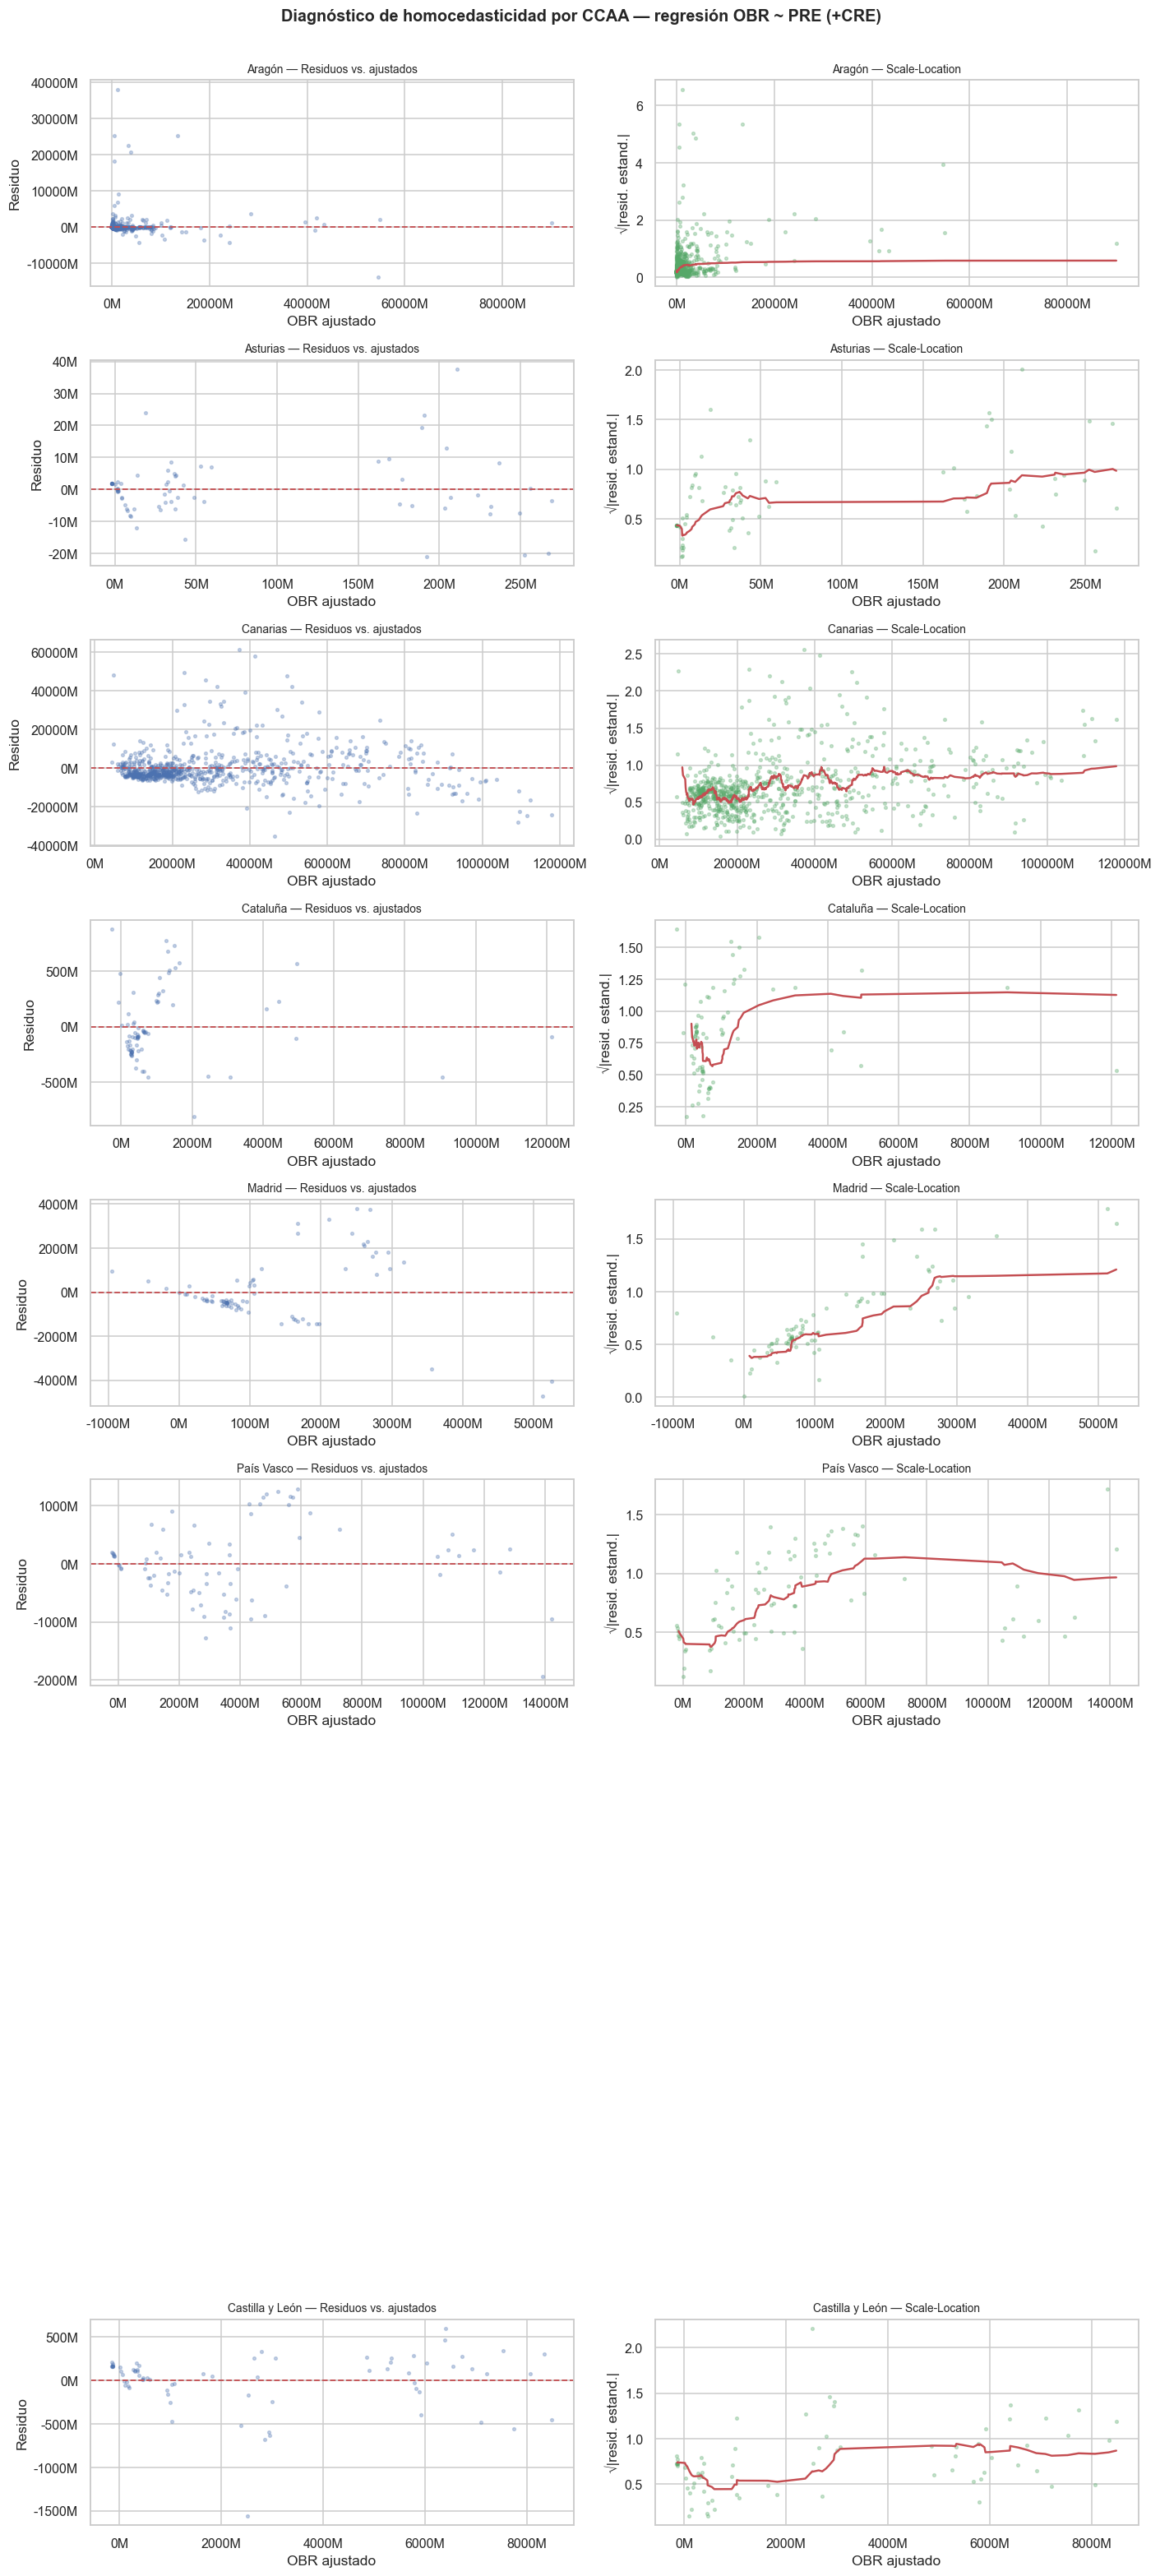

In [9]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

def ols_obr_pre(df: pd.DataFrame):
    'Ajusta OBR ~ PRE (+CRE) sobre datos validos. Devuelve (modelo, X).'
    pred = ["PRE"] + (["CRE"] if "CRE" in df.columns else [])
    d = df.dropna(subset=["OBR"] + pred)
    d = d[(d["OBR"].abs() < MAX_IMPORTE)]
    for c in pred:
        d = d[d[c].abs() < MAX_IMPORTE]
    if len(d) < 50:
        return None, None
    X = sm.add_constant(d[pred])
    model = sm.OLS(d["OBR"], X).fit()
    return model, X

def grid_residuos():
    n = len(CCAA_ORDER)
    fig, axes = plt.subplots(n, 2, figsize=(13, 3.1 * n))
    axes = np.atleast_2d(axes)
    for i, slug in enumerate(CCAA_ORDER):
        m, X = ols_obr_pre(data[data["ccaa_slug"] == slug])
        ax0, ax1 = axes[i, 0], axes[i, 1]
        if m is None:
            ax0.set_visible(False); ax1.set_visible(False); continue
        fitted = m.fittedvalues
        resid = m.resid
        std_resid = np.sqrt(np.abs(resid / (resid.std() + 1e-9)))
        # residuos vs ajustados
        ax0.scatter(fitted, resid, s=6, alpha=0.3, color="#4c72b0")
        ax0.axhline(0, color="#c44e52", lw=1.2, ls="--")
        ax0.set_title(f"{ccaa_label(slug)} — Residuos vs. ajustados", fontsize=9)
        ax0.set_xlabel("OBR ajustado"); ax0.set_ylabel("Residuo")
        ax0.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
        ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
        # scale-location con tendencia
        ax1.scatter(fitted, std_resid, s=6, alpha=0.3, color="#55a868")
        try:
            idx = np.argsort(fitted.values)
            xs = fitted.values[idx]
            ys = pd.Series(std_resid.values[idx]).rolling(max(20, len(xs)//20), min_periods=5).mean()
            ax1.plot(xs, ys, color="#c44e52", lw=1.6)
        except Exception:
            pass
        ax1.set_title(f"{ccaa_label(slug)} — Scale-Location", fontsize=9)
        ax1.set_xlabel("OBR ajustado"); ax1.set_ylabel("√|resid. estand.|")
        ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
    fig.suptitle("Diagnóstico de homocedasticidad por CCAA — regresión OBR ~ PRE (+CRE)",
                 y=1.003, fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / "residuos_homocedasticidad.png", bbox_inches="tight", dpi=110)
    plt.show()

grid_residuos()

### 5.2 · Tests de homocedasticidad por CCAA

- **Breusch-Pagan / White:** sobre la regresión `OBR ~ PRE (+CRE)`. *p* < 0.05 ⇒ heterocedástico.
- **Levene:** compara la varianza de `ejecutado_pct` **entre capítulos económicos** (robusto a no normalidad).

In [10]:
def tabla_homocedasticidad() -> pd.DataFrame:
    rows = []
    for slug in CCAA_ORDER:
        df = data[data["ccaa_slug"] == slug]
        row = {"CCAA": ccaa_label(slug)}
        # Breusch-Pagan + White
        m, X = ols_obr_pre(df)
        if m is not None:
            try:
                _, pbp, _, _ = het_breuschpagan(m.resid, m.model.exog)
                row["p(Breusch-Pagan)"] = _fmt_p(pbp)
                row["BP"] = "Heteroced." if pbp < ALPHA else "Homoced."
            except Exception:
                row["p(Breusch-Pagan)"] = "—"; row["BP"] = "—"
            try:
                _, pw, _, _ = het_white(m.resid, m.model.exog)
                row["p(White)"] = _fmt_p(pw)
            except Exception:
                row["p(White)"] = "—"
        else:
            row.update({"p(Breusch-Pagan)": "—", "BP": "—", "p(White)": "—"})
        # Levene entre capítulos
        if {"capitulo_id", "ejecutado_pct"} <= set(df.columns):
            d = df.dropna(subset=["capitulo_id", "ejecutado_pct"]).copy()
            d["cap"] = d["capitulo_id"].astype(int)
            grupos = [g["ejecutado_pct"].clip(-5, 5).values
                      for _, g in d.groupby("cap") if len(g) >= 20]
            if len(grupos) >= 2:
                W, pl = stats.levene(*grupos, center="median")
                row["p(Levene·cap)"] = _fmt_p(pl)
                row["Levene"] = "Heteroced." if pl < ALPHA else "Homoced."
            else:
                row["p(Levene·cap)"] = "—"; row["Levene"] = "—"
        rows.append(row)
    return pd.DataFrame(rows)

display(tabla_homocedasticidad())

,CCAA,p(Breusch-Pagan),BP,p(White),p(Levene·cap),Levene
0,Aragón,6.18e-17,Heteroced.,2.65e-20,6.50e-38,Heteroced.
1,Asturias,0.0072,Heteroced.,0.0137,—,—
2,Canarias,1.07e-09,Heteroced.,6.79e-47,—,—
3,Cataluña,0.2163,Homoced.,2.58e-07,—,—
4,Madrid,1.56e-13,Heteroced.,2.32e-13,—,—
5,País Vasco,0.0070,Heteroced.,0.0008,—,—
6,Illes Balears,—,—,—,—,—
7,C.-La Mancha,—,—,—,—,—
8,Castilla y León,0.0217,Heteroced.,0.0333,—,—
9,AGE (nacional),—,—,—,—,—


> #### 📚 Fundamento y referencias (homocedasticidad)
>
> La regresión por MCO asume **homocedasticidad** (varianza constante del error). Su incumplimiento
> **no sesga** los coeficientes, pero **invalida los errores estándar** y, con ellos, los contrastes
> _t_/_F_, los _p_-valores y los intervalos de confianza (Gujarati & Porter, 2010; Wooldridge, 2015).
> Por eso la heterocedasticidad detectada justifica usar modelos robustos (árboles) o errores
> estándar robustos.
>
> - **Breusch-Pagan:** regresión auxiliar de los residuos² sobre los regresores; **asume errores
>   normales** → con datos no normales puede sobre-rechazar.
> - **White:** versión **general** (incluye cuadrados y productos cruzados); **no asume forma ni
>   normalidad** → más robusto, pero gasta más grados de libertad.
> - **Levene** con `center="median"` = variante **Brown-Forsythe**, robusta a la no-normalidad;
>   compara varianzas entre capítulos.
>
> **Referencias**
> - Gujarati, D. N., & Porter, D. C. (2010). *Econometría* (5.ª ed.). McGraw-Hill.
> - Wooldridge, J. M. (2015). *Introducción a la econometría: un enfoque moderno* (5.ª ed.). Cengage Learning.
> - Breusch, T. S., & Pagan, A. R. (1979). A simple test for heteroscedasticity and random coefficient variation. *Econometrica, 47*(5), 1287–1294.
> - White, H. (1980). A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity. *Econometrica, 48*(4), 817–838.
> - Levene, H. (1960). Robust tests for equality of variances. En *Contributions to Probability and Statistics* (pp. 278–292). Stanford University Press.
> - Brown, M. B., & Forsythe, A. B. (1974). Robust tests for the equality of variances. *Journal of the American Statistical Association, 69*(346), 364–367.

### 5.3 · Dispersión de la tasa de ejecución entre capítulos (visión de varianza)

Boxplots de `ejecutado_pct` por capítulo para algunas CCAA: si las cajas tienen **anchuras
muy distintas**, la varianza no es constante entre grupos (apoya el resultado de Levene).

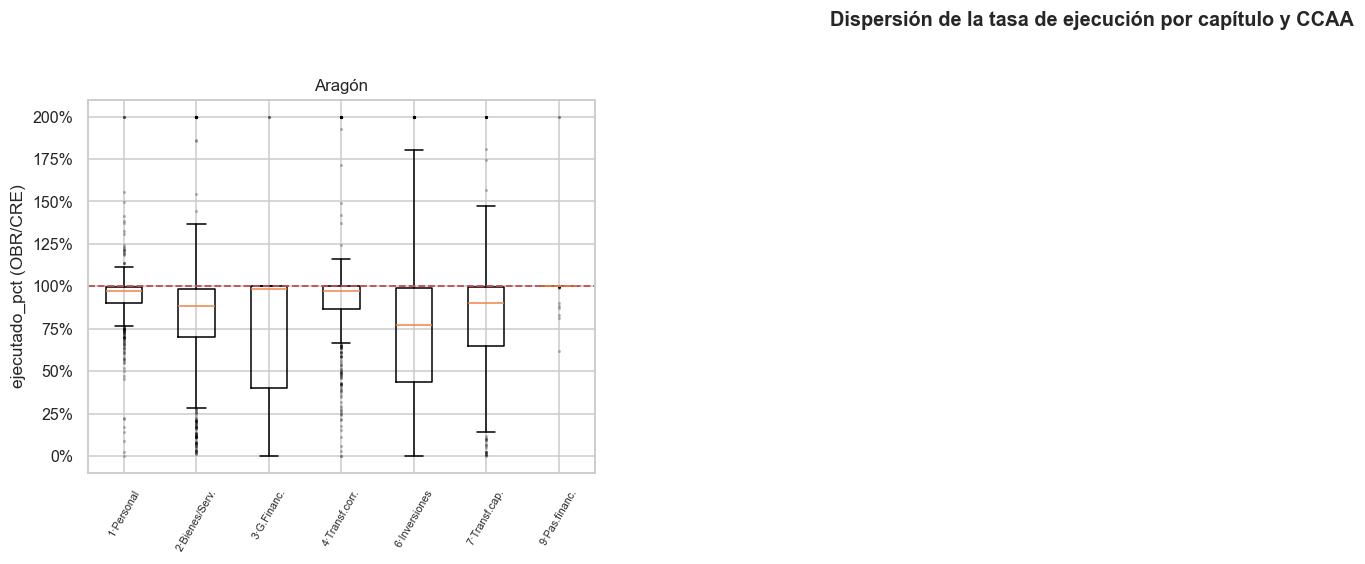

In [11]:
def boxplots_por_capitulo(slugs=None, max_ccaa=4):
    slugs = slugs or CCAA_ORDER[:max_ccaa]
    fig, axes = plt.subplots(1, len(slugs), figsize=(5 * len(slugs), 5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, slug in zip(axes, slugs):
        df = data[data["ccaa_slug"] == slug]
        d = df.dropna(subset=["capitulo_id", "ejecutado_pct"]).copy()
        d["cap"] = d["capitulo_id"].astype(int)
        caps = sorted(c for c in d["cap"].unique() if (d["cap"] == c).sum() >= 20)
        datos = [d.loc[d["cap"] == c, "ejecutado_pct"].clip(0, 2).values for c in caps]
        if not datos:
            ax.set_visible(False); continue
        ax.boxplot(datos, tick_labels=[cap_label(c) for c in caps],
                   flierprops=dict(marker=".", markersize=2, alpha=0.25))
        ax.axhline(1.0, color="#c44e52", ls="--", lw=1.2)
        ax.set_title(ccaa_label(slug), fontsize=11)
        ax.set_ylabel("ejecutado_pct (OBR/CRE)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.tick_params(axis="x", rotation=60, labelsize=7)
    fig.suptitle("Dispersión de la tasa de ejecución por capítulo y CCAA", y=1.02,
                 fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / "boxplot_ejecucion_capitulo.png", bbox_inches="tight", dpi=110)
    plt.show()

boxplots_por_capitulo()

## 6 · Contrastes no paramétricos

Dado que las secciones 4 y 5 **rechazan la normalidad y la homocedasticidad**, los contrastes de
hipótesis se realizan con **pruebas no paramétricas**: no asumen distribución normal ni varianzas
iguales y trabajan sobre **rangos**, por lo que son robustas a outliers y colas pesadas. Cada una
sustituye a su equivalente paramétrico:

| Prueba no paramétrica | Sustituye a | Qué contrasta aquí |
|---|---|---|
| **Spearman** (ρ) | Correlación de Pearson | Asociación monótona OBR ↔ PRE/CRE |
| **Kruskal-Wallis** (H) | ANOVA de una vía | ¿Difiere la tasa de ejecución entre **capítulos**? |
| **Mann-Whitney** (U) | t-Student (2 grupos) | ¿Ejecuta distinto el gasto **corriente** que el de **capital**? |

Interpretación común: _p_ < 0.05 ⇒ se rechaza H₀ (no hay asociación / los grupos son iguales).

### 6.1 · Correlación de Spearman (OBR ↔ PRE y OBR ↔ CRE)

Mide la asociación **monótona** (por rangos) entre obligaciones y crédito, sin asumir linealidad
ni normalidad. ρ cercano a 1 ⇒ a mayor crédito, mayor ejecución de obligaciones.

,CCAA,n,"rho(OBR,PRE)",p(OBR~PRE),signif.,"rho(OBR,CRE)",p(OBR~CRE)
0,Aragón,5910,0.878,0.00e+00,Sí,0.962,0.00e+00
1,Asturias,63,0.933,1.04e-28,Sí,0.935,3.35e-29
2,Canarias,764,0.798,1.98e-169,Sí,0.970,0.00e+00
3,Cataluña,122,0.792,1.86e-27,Sí,0.927,2.48e-33
4,Madrid,74,0.738,6.51e-14,Sí,0.631,1.34e-09
5,País Vasco,70,0.929,4.71e-31,Sí,0.965,2.97e-41
6,Illes Balears,21,0.959,6.75e-12,Sí,0.970,3.81e-13
7,C.-La Mancha,13,0.676,0.0112,Sí,NaN,—
8,Castilla y León,72,0.985,1.25e-55,Sí,0.989,2.02e-59
9,AGE (nacional),47,0.251,0.0890,No,NaN,—


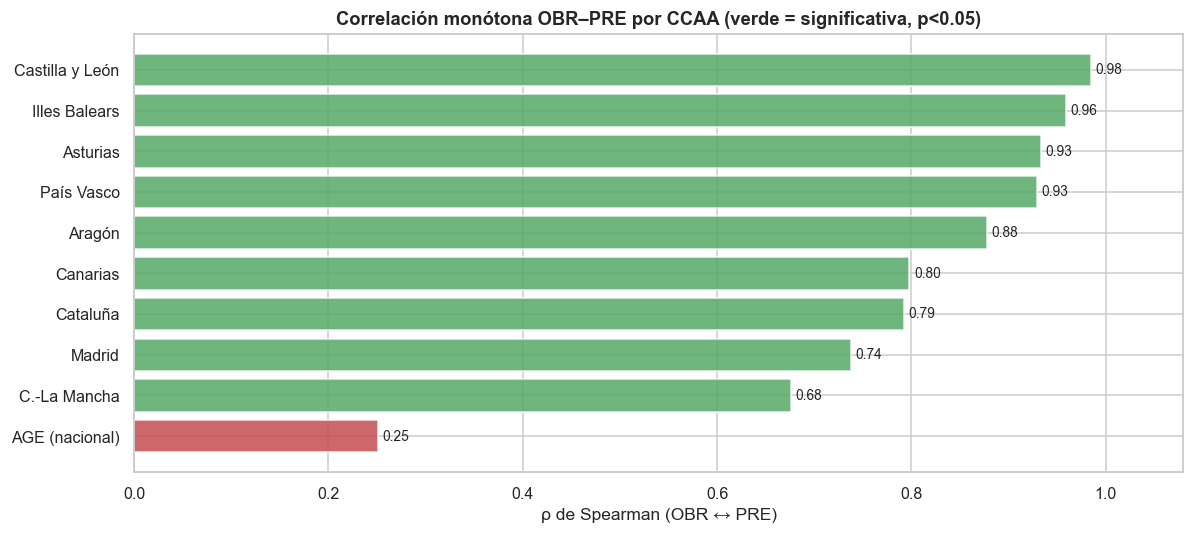

In [12]:
from scipy.stats import spearmanr, kruskal, mannwhitneyu

def tabla_spearman():
    rows = []
    for slug in CCAA_ORDER:
        d = data[data["ccaa_slug"] == slug]
        a = d.dropna(subset=["OBR", "PRE"])
        a = a[(a["OBR"] > 0) & (a["PRE"] > 0)]
        if len(a) < 10:
            continue
        rho_p, p_p = spearmanr(a["OBR"], a["PRE"])
        row = {"CCAA": ccaa_label(slug), "n": len(a),
               "rho(OBR,PRE)": round(rho_p, 3), "p(OBR~PRE)": _fmt_p(p_p),
               "signif.": "Sí" if p_p < ALPHA else "No"}
        if "CRE" in d.columns:
            b = d.dropna(subset=["OBR", "CRE"])
            b = b[(b["OBR"] > 0) & (b["CRE"] > 0)]
            if len(b) >= 10:
                rho_c, p_c = spearmanr(b["OBR"], b["CRE"])
                row["rho(OBR,CRE)"] = round(rho_c, 3)
                row["p(OBR~CRE)"] = _fmt_p(p_c)
            else:
                row["rho(OBR,CRE)"] = np.nan
                row["p(OBR~CRE)"] = "—"
        rows.append(row)
    return pd.DataFrame(rows)

spearman_df = tabla_spearman()
display(spearman_df)

fig, ax = plt.subplots(figsize=(11, 5))
sub = spearman_df.sort_values("rho(OBR,PRE)")
colors = ["#55a868" if s == "Sí" else "#c44e52" for s in sub["signif."]]
bars = ax.barh(sub["CCAA"], sub["rho(OBR,PRE)"], color=colors, alpha=0.85)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel("ρ de Spearman (OBR ↔ PRE)")
ax.set_title("Correlación monótona OBR–PRE por CCAA (verde = significativa, p<0.05)",
             fontsize=12, weight="bold")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "spearman_obr_pre.png", bbox_inches="tight", dpi=110)
plt.show()

> #### 🎯 Implicancias para el TFM (6.1)
>
> **Hallazgo:** correlación monótona OBR–PRE **fuerte y significativa** en casi todas las CCAA
> (ρ ≈ 0.7–0.99); la única excepción es AGE (ρ ≈ 0.25, no significativa, por escasez de datos).
>
> - **Predictor clave del modelo.** Que a mayor crédito inicial (PRE) correspondan mayores
>   obligaciones (OBR) de forma monótona confirma que **PRE es un predictor sólido de OBR**, base
>   del modelo predictivo de `04_models`.
> - **Refuerza la metodología.** Spearman (por rangos) sustituye a Pearson —no válido aquí por la
>   no-normalidad del apartado 4— y capta la asociación aun sin relación lineal.
>
> **Matices:** Spearman mide asociación **monótona, no lineal** ni causal; AGE queda fuera por
> escasez de datos (n = 47), no porque no exista relación.

### 6.2 · Kruskal-Wallis (tasa de ejecución entre capítulos)

Equivalente no paramétrico del ANOVA: contrasta si la **distribución** de `ejecutado_pct` es igual
en todos los capítulos económicos. Complementa al test de Levene del 5.2 (Levene mira la *varianza*;
Kruskal-Wallis, la *tendencia central por rangos*).

,Ámbito,n_capítulos,H,p,Conclusión (α=.05)
0,Núcleo (agregado),9,473.0,4.25e-97,Difieren
1,Aragón,7,440.0,6.89e-92,Difieren


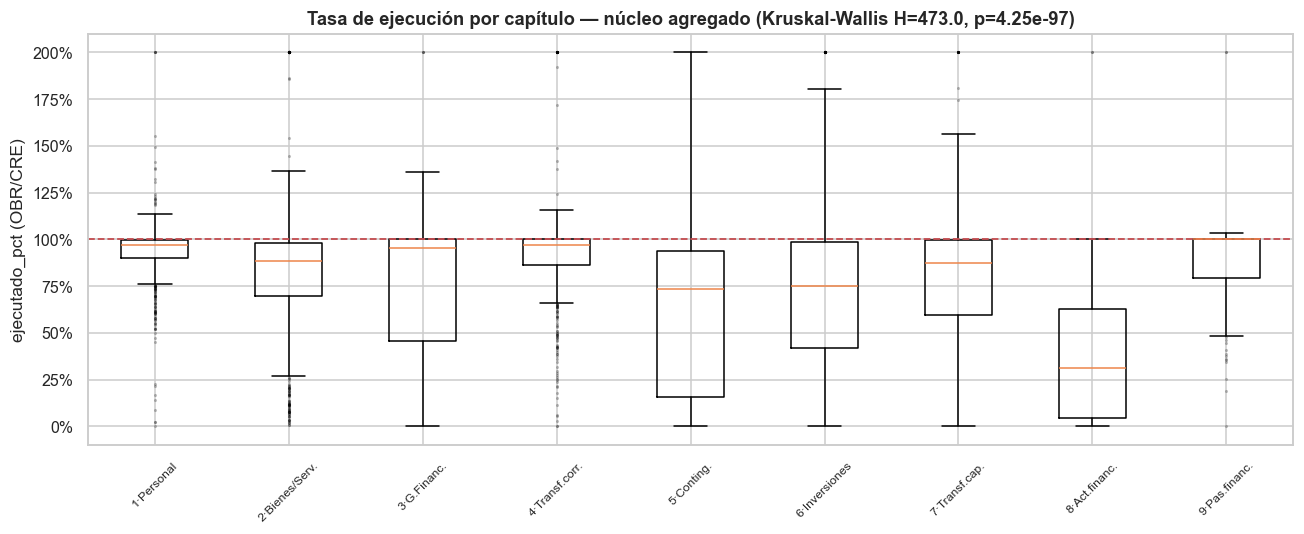

In [13]:
def _grupos_cap(d, minn=20):
    d = d.dropna(subset=["capitulo_id", "ejecutado_pct"]).copy()
    d["cap"] = d["capitulo_id"].astype(int)
    d["e"] = d["ejecutado_pct"].clip(0, 2)
    return [(c, g["e"].values) for c, g in d.groupby("cap") if len(g) >= minn]

def tabla_kruskal():
    rows = []
    ambitos = [("Núcleo (agregado)", data)] + \
              [(ccaa_label(s), data[data["ccaa_slug"] == s]) for s in CCAA_ORDER]
    for label, d in ambitos:
        gp = _grupos_cap(d)
        if len(gp) >= 2:
            H, p = kruskal(*[v for _, v in gp])
            rows.append({"Ámbito": label, "n_capítulos": len(gp),
                         "H": round(H, 1), "p": _fmt_p(p),
                         "Conclusión (α=.05)": "Difieren" if p < ALPHA else "Iguales"})
    return pd.DataFrame(rows)

kruskal_df = tabla_kruskal()
display(kruskal_df)

dd = data.dropna(subset=["capitulo_id", "ejecutado_pct"]).copy()
dd["cap"] = dd["capitulo_id"].astype(int)
caps = [c for c in range(1, 10) if (dd["cap"] == c).sum() >= 20]
datos = [dd.loc[dd["cap"] == c, "ejecutado_pct"].clip(0, 2).values for c in caps]
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(datos, tick_labels=[cap_label(c) for c in caps],
           flierprops=dict(marker=".", markersize=2, alpha=0.25))
ax.axhline(1.0, color="#c44e52", ls="--", lw=1.2)
ax.set_ylabel("ejecutado_pct (OBR/CRE)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=45, labelsize=8)
H0 = kruskal_df.iloc[0]
ax.set_title(f"Tasa de ejecución por capítulo — núcleo agregado "
             f"(Kruskal-Wallis H={H0['H']}, p={H0['p']})", fontsize=12, weight="bold")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "kruskal_capitulos.png", bbox_inches="tight", dpi=110)
plt.show()

> #### 🎯 Implicancias para el TFM (6.2)
>
> **Hallazgo:** la tasa de ejecución **difiere significativamente entre capítulos** (núcleo
> agregado: H ≈ 473, _p_ ≈ 4×10⁻⁹⁷; replicado en Aragón) → el capítulo económico condiciona cuánto
> crédito se ejecuta.
>
> - **Predictor para el modelo.** Justifica incluir el **capítulo** (`capitulo_id`) como variable
>   explicativa en `04_models`.
> - **Complementa la homocedasticidad (5.2).** Levene mostró varianzas distintas entre capítulos;
>   Kruskal-Wallis añade que también difiere la **tendencia central** → el capítulo afecta tanto al
>   nivel como a la dispersión de la ejecución.
>
> **Matices:** por CCAA solo es calculable en Aragón (el resto no alcanza ≥20 obs. por capítulo); la
> diferencia es **real** (las medianas por capítulo difieren), no un artefacto del _n_ grande; el
> test indica *que* difieren, no *qué* capítulos (requeriría comparaciones post-hoc, p. ej. Dunn).

### 6.3 · Mann-Whitney U (gasto corriente vs. de capital)

Compara `ejecutado_pct` de los **capítulos corrientes** (1–4: personal, bienes/servicios,
financieros, transferencias corrientes) frente a los de **capital** (6–7: inversiones y
transferencias de capital). Hipótesis sustantiva: la inversión suele **infraejecutarse** más
que el gasto corriente.

,Ámbito,n corr.,mediana corr.,n capital,mediana capital,U,p,Dirección
0,Núcleo (agregado),3519,0.951,1289,0.815,2846444,5.21e-42,Capital ejecuta menos
1,Aragón,3361,0.952,1205,0.840,2492134,1.02e-32,Capital ejecuta menos
2,País Vasco,30,0.521,20,0.425,442,0.0051,Capital ejecuta menos


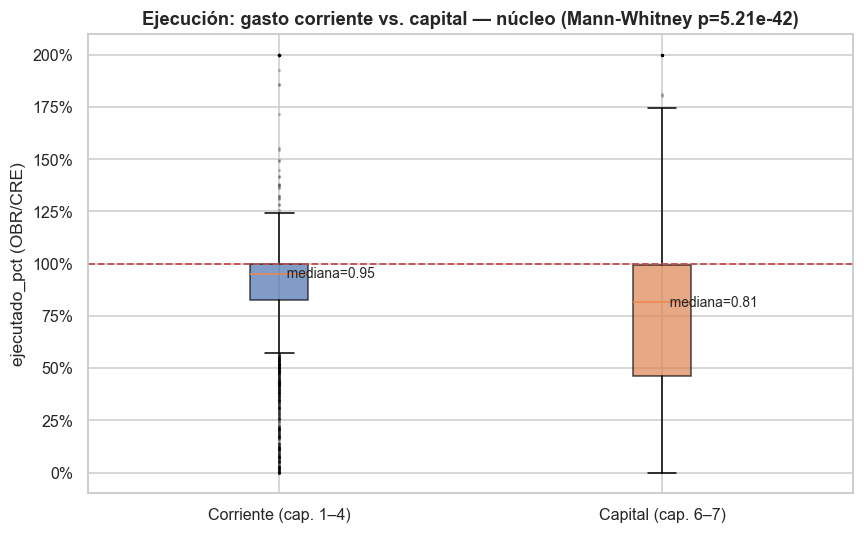

In [14]:
CORRIENTES, CAPITAL = [1, 2, 3, 4], [6, 7]

def _ej(d):
    d = d.dropna(subset=["capitulo_id", "ejecutado_pct"]).copy()
    d["cap"] = d["capitulo_id"].astype(int)
    d["e"] = d["ejecutado_pct"].clip(0, 2)
    return d

def tabla_mannwhitney():
    rows = []
    def run(label, d):
        corr = d[d["cap"].isin(CORRIENTES)]["e"]
        cap = d[d["cap"].isin(CAPITAL)]["e"]
        if len(corr) >= 20 and len(cap) >= 20:
            U, p = mannwhitneyu(corr, cap, alternative="two-sided")
            if p >= ALPHA:
                direc = "Sin diferencia"
            elif cap.median() < corr.median():
                direc = "Capital ejecuta menos"
            else:
                direc = "Capital ejecuta más"
            rows.append({"Ámbito": label,
                         "n corr.": len(corr), "mediana corr.": round(corr.median(), 3),
                         "n capital": len(cap), "mediana capital": round(cap.median(), 3),
                         "U": int(U), "p": _fmt_p(p), "Dirección": direc})
    run("Núcleo (agregado)", _ej(data))
    for slug in CCAA_ORDER:
        run(ccaa_label(slug), _ej(data[data["ccaa_slug"] == slug]))
    return pd.DataFrame(rows)

mw_df = tabla_mannwhitney()
display(mw_df)

de = _ej(data)
g_corr = de[de["cap"].isin(CORRIENTES)]["e"]
g_cap = de[de["cap"].isin(CAPITAL)]["e"]
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([g_corr.values, g_cap.values],
                tick_labels=["Corriente (cap. 1–4)", "Capital (cap. 6–7)"],
                patch_artist=True, flierprops=dict(marker=".", markersize=2, alpha=0.25))
for patch, color in zip(bp["boxes"], ["#4c72b0", "#dd8452"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(1.0, color="#c44e52", ls="--", lw=1.2)
for i, g in enumerate([g_corr, g_cap], start=1):
    ax.text(i, g.median(), f"  mediana={g.median():.2f}", va="center", fontsize=9)
ax.set_ylabel("ejecutado_pct (OBR/CRE)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
mw0 = mw_df.iloc[0]
ax.set_title(f"Ejecución: gasto corriente vs. capital — núcleo "
             f"(Mann-Whitney p={mw0['p']})", fontsize=12, weight="bold")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "mannwhitney_corriente_capital.png", bbox_inches="tight", dpi=110)
plt.show()

> #### 🎯 Implicancias para el TFM (6.3)
>
> **Hallazgo:** el gasto de **capital se ejecuta significativamente menos** que el corriente
> (medianas ≈ 0.82 vs 0.95; _p_ ≈ 5×10⁻⁴²), de forma consistente en el núcleo agregado y en las
> CCAA con datos suficientes (Aragón, País Vasco). Confirma empíricamente la **infraejecución
> sistemática de la inversión**, un fenómeno conocido en finanzas públicas.
>
> - **Predictor para el modelo.** Que la ejecución dependa de si el gasto es corriente o de capital
>   justifica usar el **capítulo económico** (`capitulo_id`) como variable explicativa en la fase
>   `04_models`.
> - **Refuerza la metodología.** Es un caso aplicado de prueba **no paramétrica** sobre datos no
>   normales, cerrando el argumento *supuestos (4–5) → método*.
> - **Relevancia de política pública.** Aporta una conclusión legible y accionable para el capítulo
>   de discusión, más allá del rendimiento del modelo.
>
> **Matices (para una defensa rigurosa):**
> - Solo calculable en el núcleo agregado, Aragón y País Vasco (el resto no alcanza ≥20 obs. por
>   grupo); el agregado está **dominado por Aragón** (~86% de los datos).
> - El test indica **asociación, no causa**: no explica *por qué* (ciclos de inversión plurianuales,
>   licitaciones), solo *que* difieren.
> - Mann-Whitney contrasta distribuciones; la lectura direccional es válida aquí porque las medianas
>   difieren en el mismo sentido en todos los ámbitos.

### Lectura de los contrastes

- **Spearman:** la asociación monótona OBR–PRE es **fuerte y significativa** en casi todas las CCAA
  (ρ ≈ 0.7–0.99); la excepción es AGE (datos escasos). El crédito inicial es un **predictor sólido**
  de las obligaciones, aun sin relación lineal ni normalidad.
- **Kruskal-Wallis:** la tasa de ejecución **difiere significativamente entre capítulos**
  (núcleo agregado: H ≈ 473, p ≈ 4×10⁻⁹⁷) → el capítulo condiciona la ejecución.
- **Mann-Whitney:** el gasto de **capital se ejecuta significativamente menos** que el corriente
  (medianas ≈ 0.82 vs 0.95; p ≈ 5×10⁻⁴²), confirmando la infraejecución típica de la inversión.

Estos resultados **respaldan empíricamente** la decisión metodológica del apartado 9.

## 7 · Tendencias temporales de las variables clave

Series anuales etiquetadas por CCAA: contextualizan los supuestos anteriores y muestran
la evolución del gasto (OBR) y de la tasa de ejecución media.

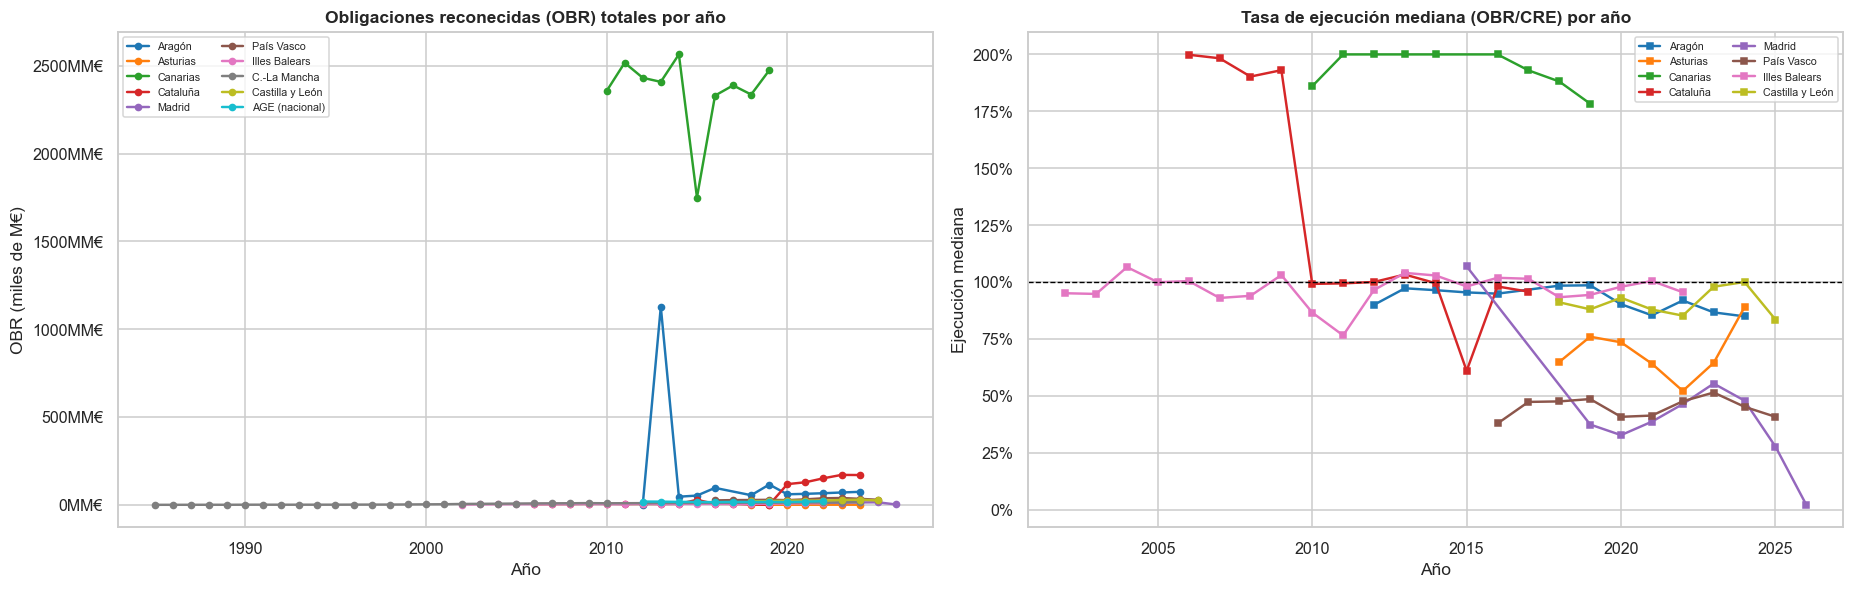

In [15]:
def tendencias():
    fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
    colors = plt.cm.tab10.colors
    # OBR total anual por CCAA
    for i, slug in enumerate(CCAA_ORDER):
        g = (data[data["ccaa_slug"] == slug]
             .groupby("anio")["OBR"].sum().sort_index())
        g = g[g > 0]
        if g.empty:
            continue
        axes[0].plot(g.index, g.values / 1e9, "o-", color=colors[i % 10],
                     lw=1.6, ms=4, label=ccaa_label(slug))
    axes[0].set_title("Obligaciones reconecidas (OBR) totales por año", weight="bold")
    axes[0].set_xlabel("Año"); axes[0].set_ylabel("OBR (miles de M€)")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}MM€"))
    axes[0].legend(fontsize=7, ncol=2)

    # tasa de ejecución mediana anual por CCAA
    for i, slug in enumerate(CCAA_ORDER):
        g = (data[data["ccaa_slug"] == slug]
             .dropna(subset=["ejecutado_pct"])
             .assign(e=lambda d: d["ejecutado_pct"].clip(0, 2))
             .groupby("anio")["e"].median().sort_index())
        if g.empty:
            continue
        axes[1].plot(g.index, g.values * 100, "s-", color=colors[i % 10],
                     lw=1.6, ms=4, label=ccaa_label(slug))
    axes[1].axhline(100, color="black", ls="--", lw=0.9)
    axes[1].set_title("Tasa de ejecución mediana (OBR/CRE) por año", weight="bold")
    axes[1].set_xlabel("Año"); axes[1].set_ylabel("Ejecución mediana")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[1].legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / "tendencias.png", bbox_inches="tight", dpi=110)
    plt.show()

tendencias()

## 8 · Análisis descriptivo — CCAA con solo presupuesto inicial (PRE)

**Murcia, Galicia y Comunitat Valenciana** solo publican la fase **PRE** (crédito inicial
aprobado): no hay obligaciones reconocidas (OBR), por lo que **no entran en el análisis de
supuestos ni en el modelo predictivo** (no hay variable objetivo de ejecución). Aquí se
estudian **solo de forma descriptiva**: cuánto y en qué planifican gastar.

> ⚠️ **Tamaño muestral:** Murcia aporta datos robustos, pero Galicia y C. Valenciana tienen
> muy pocas filas (apenas unas decenas). Sus estadísticos son **orientativos**, no concluyentes.

In [16]:
CCAA_PRE = ["murcia", "galicia", "comunidad-valenciana"]

frames_pre = []
for slug in CCAA_PRE:
    df = load_ccaa(slug)          # función definida en la sección 2
    if df.empty or "PRE" not in df.columns:
        print(f"  [SKIP] sin PRE: {slug}")
        continue
    df = df[df["PRE"].abs() < MAX_IMPORTE].copy()   # mismo saneo que el núcleo
    df["ccaa_slug"] = slug
    df["nombre"] = ccaa_label(slug)
    frames_pre.append(df)

data_pre = pd.concat(frames_pre, ignore_index=True)
PRE_ORDER = [s for s in CCAA_PRE if s in data_pre["ccaa_slug"].unique()]
print("Filas PRE cargadas:")
print(data_pre.groupby("nombre")["PRE"].agg(n="count", suma_M=lambda s: s.sum() / 1e6).round(1))

Filas PRE cargadas:
                  n    suma_M
nombre                       
C. Valenciana    22    3135.5
Galicia          63  267514.6
Murcia         1576   79136.3


### 8.1 · Estadísticos descriptivos de PRE por CCAA

Media, mediana, desviación típica, coeficiente de variación (CV) y percentiles del crédito
inicial por línea presupuestaria. La fila *Total €* es la suma del presupuesto planificado.

In [17]:
def tabla_descriptiva_pre() -> pd.DataFrame:
    rows = []
    for slug in PRE_ORDER:
        s = pd.to_numeric(data_pre.loc[data_pre["ccaa_slug"] == slug, "PRE"], errors="coerce").dropna()
        s = s[np.isfinite(s) & (s >= 0)]
        if len(s) < 3:
            continue
        mean = s.mean()
        rows.append({
            "CCAA": ccaa_label(slug),
            "n": len(s),
            "Total M€": round(s.sum() / 1e6, 1),
            "media €": round(mean, 2),
            "mediana €": round(s.median(), 2),
            "desv_típica €": round(s.std(ddof=1), 2),
            "CV": round(s.std(ddof=1) / mean, 3) if mean else np.nan,
            "p25 €": round(s.quantile(0.25), 2),
            "p75 €": round(s.quantile(0.75), 2),
            "máx €": round(s.max(), 2),
        })
    return pd.DataFrame(rows)

display(tabla_descriptiva_pre())

,CCAA,n,Total M€,media €,mediana €,desv_típica €,CV,p25 €,p75 €,máx €
0,Murcia,1576,79136.3,5.021336e+07,1.857470e+06,3.357698e+08,6.687,400345.0,7.519538e+06,5.187353e+09
1,Galicia,63,267514.6,4.246264e+09,2.492057e+09,4.309417e+09,1.015,331700711.0,6.924297e+09,1.477519e+10
2,C. Valenciana,22,3135.5,1.425219e+08,9.544726e+07,1.588137e+08,1.114,21012500.0,2.086872e+08,6.215334e+08


### 8.2 · Distribución del crédito inicial (PRE)

Histograma en escala log1p (el importe abarca varios órdenes de magnitud) con la mediana
marcada. Igual que en el núcleo, se observa fuerte asimetría: muchas partidas pequeñas y
pocas muy grandes.

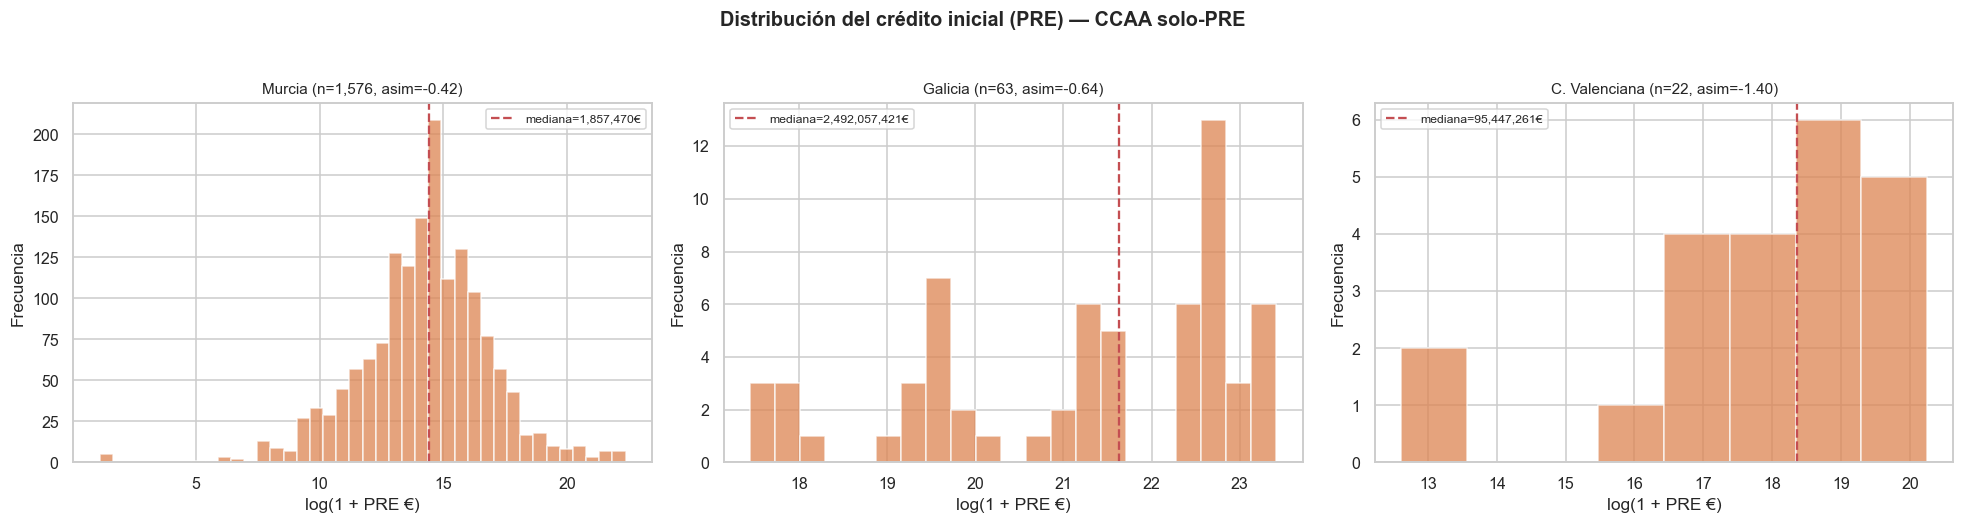

In [18]:
fig, axes = plt.subplots(1, len(PRE_ORDER), figsize=(6 * len(PRE_ORDER), 4.6), squeeze=False)
axes = axes.ravel()
for ax, slug in zip(axes, PRE_ORDER):
    s = pd.to_numeric(data_pre.loc[data_pre["ccaa_slug"] == slug, "PRE"], errors="coerce").dropna()
    s = s[s > 0]
    logs = np.log1p(s)
    ax.hist(logs, bins=min(40, max(8, len(s) // 3)), color="#dd8452", alpha=0.75, edgecolor="white")
    ax.axvline(logs.median(), color="#c44e52", ls="--", lw=1.5, label=f"mediana={s.median():,.0f}€")
    ax.set_title(f"{ccaa_label(slug)} (n={len(s):,}, asim={stats.skew(logs):.2f})", fontsize=10)
    ax.set_xlabel("log(1 + PRE €)"); ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)
fig.suptitle("Distribución del crédito inicial (PRE) — CCAA solo-PRE", y=1.03, fontsize=13, weight="bold")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "pre_solo_distribucion.png", bbox_inches="tight", dpi=110)
plt.show()

### 8.3 · Composición y evolución del presupuesto

Izquierda: reparto del PRE total por **capítulo económico** (en qué se planifica gastar).
Derecha: **evolución anual** del presupuesto inicial total por CCAA.

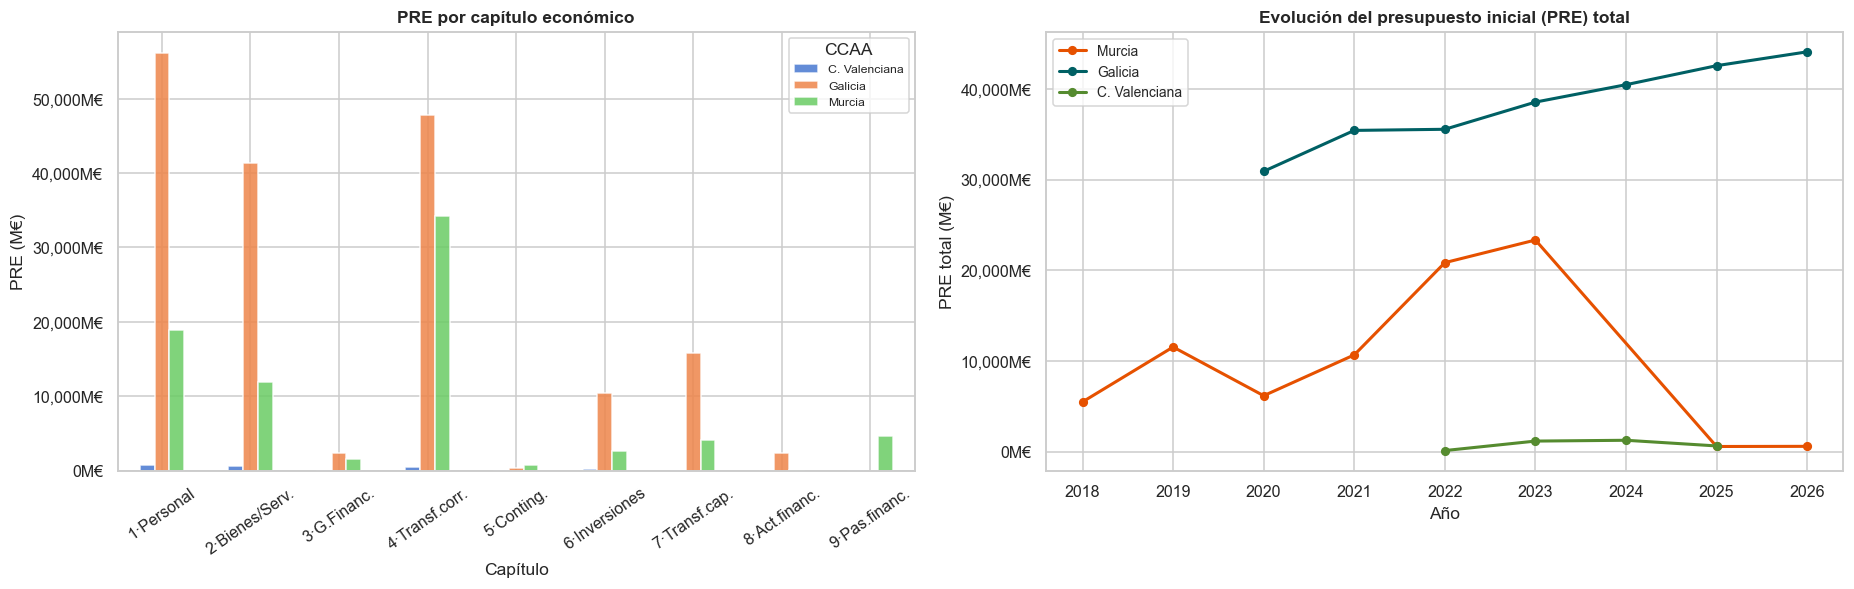

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

# --- PRE por capítulo (suma) por CCAA ---
d = data_pre.dropna(subset=["capitulo_id"]).copy()
d["cap"] = d["capitulo_id"].astype(int)
d["cap_label"] = d["cap"].map(cap_label)
pivot = (d.groupby(["nombre", "cap_label"])["PRE"].sum() / 1e6).unstack(fill_value=0)
orden_cap = [cap_label(i) for i in range(1, 10) if cap_label(i) in pivot.columns]
pivot = pivot[orden_cap]
pivot.T.plot(kind="bar", ax=axes[0], alpha=0.85)
axes[0].set_title("PRE por capítulo económico", weight="bold")
axes[0].set_xlabel("Capítulo"); axes[0].set_ylabel("PRE (M€)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}M€"))
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="CCAA", fontsize=8)

# --- Evolución PRE total por año ---
palette = {"Murcia": "#e65100", "Galicia": "#006064", "C. Valenciana": "#558b2f"}
for slug in PRE_ORDER:
    g = (data_pre[data_pre["ccaa_slug"] == slug]
         .groupby("anio")["PRE"].sum().sort_index() / 1e6)
    nombre = ccaa_label(slug)
    axes[1].plot(g.index, g.values, "o-", lw=2, ms=5, label=nombre,
                 color=palette.get(nombre))
axes[1].set_title("Evolución del presupuesto inicial (PRE) total", weight="bold")
axes[1].set_xlabel("Año"); axes[1].set_ylabel("PRE total (M€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}M€"))
axes[1].legend(fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "pre_solo_composicion.png", bbox_inches="tight", dpi=110)
plt.show()

## 9 · Síntesis y decisión metodológica

Resumen automático: porcentaje de CCAA donde se **rechaza** normalidad / homocedasticidad.

In [20]:
print("RESUMEN DE NORMALIDAD (por variable):")
for var, cfg in VARIABLES.items():
    t = tabla_normalidad(var)
    if t.empty:
        continue
    n_norm = (t["¿Normal?"] == "Sí").sum()
    print(f"  · {cfg['label']:<34}: {n_norm}/{len(t)} CCAA normales "
          f"-> {'mayoría NO normal' if n_norm <= len(t)/2 else 'mayoría normal'}")

th = tabla_homocedasticidad()
bp_done = th[th["BP"] != "—"]
lev_done = th[th["Levene"] != "—"]
n_bp_het = (bp_done["BP"] == "Heteroced.").sum()
n_lev_het = (lev_done["Levene"] == "Heteroced.").sum()
print(f"\nHOMOCEDASTICIDAD (solo CCAA con datos suficientes):")
print(f"  · Breusch-Pagan heterocedástico en {n_bp_het}/{len(bp_done)} CCAA con modelo")
print(f"  · Levene (entre capítulos) heterocedástico en {n_lev_het}/{len(lev_done)} CCAA con datos por capítulo")

RESUMEN DE NORMALIDAD (por variable):
  · Obligaciones reconocidas (OBR, €) : 2/10 CCAA normales -> mayoría NO normal
  · Crédito inicial (PRE, €)          : 0/9 CCAA normales -> mayoría NO normal


  · Tasa de ejecución OBR/CRE         : 0/8 CCAA normales -> mayoría NO normal
  · Brecha (PRE−OBR)/PRE              : 0/9 CCAA normales -> mayoría NO normal

HOMOCEDASTICIDAD (solo CCAA con datos suficientes):
  · Breusch-Pagan heterocedástico en 6/7 CCAA con modelo
  · Levene (entre capítulos) heterocedástico en 1/1 CCAA con datos por capítulo


### Conclusión para el TFM

- **Normalidad.** Los importes en bruto (OBR, PRE) presentan fuerte asimetría positiva; aun tras
  la transformación logarítmica, los contrastes **rechazan la normalidad** en la práctica
  totalidad de CCAA, ahora por **colas pesadas (curtosis elevada)** y por la **alta sensibilidad
  de los tests con muestras grandes**. Los ratios (`ejecutado_pct`, `brecha_pct`) tampoco son
  normales (curtosis hasta 4.97 y 15.1). El veredicto se apoya en el **tamaño del efecto
  (asimetría/curtosis) y los Q-Q plots**, no solo en el _p_-valor (véase la nota del apartado 4.3).
- **Homocedasticidad.** La regresión `OBR ~ PRE (+CRE)` muestra **heterocedasticidad** en 6 de las
  7 CCAA con modelo suficiente (Breusch-Pagan y White significativos; única excepción parcial,
  Cataluña). Donde hay datos suficientes por capítulo (Aragón), el test de **Levene/Brown-Forsythe**
  confirma **varianzas distintas entre capítulos**.
- **Hallazgos del contraste no paramétrico (apartado 6).** Sobre los datos se confirma que:
  (i) el crédito inicial **PRE predice de forma monótona y significativa** las obligaciones OBR
  (Spearman ρ ≈ 0.7–0.99); (ii) la tasa de ejecución **difiere entre capítulos** (Kruskal-Wallis,
  _p_ ≈ 4×10⁻⁹⁷); y (iii) el **gasto de capital se infraejecuta** frente al corriente (Mann-Whitney,
  medianas ≈ 0.82 vs 0.95; _p_ ≈ 5×10⁻⁴²). Estos resultados respaldan incluir el **capítulo** como
  predictor y aportan una conclusión sustantiva de política pública: la infraejecución de la inversión.
- **Alcance.** El análisis de supuestos se limita a las CCAA con fase OBR. **Murcia, Galicia y
  Comunitat Valenciana** (solo PRE) quedan fuera del modelado predictivo y se tratan de forma
  meramente descriptiva (apartado 8).
- **Implicación metodológica.** Se descartan como herramienta principal las pruebas/estimadores
  que asumen normalidad y varianza constante (OLS, t-Student, ANOVA, Pearson). El contraste de
  hipótesis se realiza con **pruebas no paramétricas** (Spearman, Kruskal-Wallis, Mann-Whitney;
  apartado 6) y para el modelado predictivo, **modelos basados en árboles** (Random Forest,
  XGBoost, LightGBM), robustos a la no-normalidad y la heterocedasticidad
  (Gujarati & Porter, 2010; Wooldridge, 2015).

Todas las figuras se han guardado en `reports/estadistica_ccaa/` y las tablas en
`reports/estadistica_ccaa/tablas_estadistica.xlsx`.

## 10 · Exportación de tablas a Excel

Vuelca todas las tablas de este análisis (descriptivos, normalidad y homocedasticidad, núcleo + solo-PRE) a un único libro Excel con una hoja por tabla, listo para anexar a la memoria del TFM.

In [21]:
from datetime import datetime

def _exportar(path):
    with pd.ExcelWriter(path, engine="openpyxl") as xl:
        for var, cfg in VARIABLES.items():
            clave = var.replace("_pct", "")
            tabla_descriptiva(var).to_excel(xl, sheet_name=f"Desc_{clave}"[:31], index=False)
            tabla_normalidad(var).to_excel(xl, sheet_name=f"Normal_{clave}"[:31], index=False)
        tabla_homocedasticidad().to_excel(xl, sheet_name="Homocedasticidad", index=False)
        tabla_descriptiva_pre().to_excel(xl, sheet_name="Desc_PRE_solo", index=False)
        spearman_df.to_excel(xl, sheet_name="NoParam_Spearman", index=False)
        kruskal_df.to_excel(xl, sheet_name="NoParam_KruskalWallis", index=False)
        mw_df.to_excel(xl, sheet_name="NoParam_MannWhitney", index=False)

excel_path = REPORTS_DIR / "tablas_estadistica.xlsx"
try:
    _exportar(excel_path)
except PermissionError:
    # El fichero está abierto (p. ej. en Excel): se escribe una copia con marca temporal.
    excel_path = REPORTS_DIR / f"tablas_estadistica_{datetime.now():%Y%m%d_%H%M%S}.xlsx"
    _exportar(excel_path)
    print("  [AVISO] tablas_estadistica.xlsx estaba abierto; guardado como copia nueva.")

print(f"[OK] Excel escrito -> {excel_path}")
print("Hojas:", pd.ExcelFile(excel_path).sheet_names)

[OK] Excel escrito -> C:\Users\usuario\Documents\Master\Projects\Ejecucion_presupuestaria\reports\estadistica_ccaa\tablas_estadistica.xlsx
Hojas: ['Desc_OBR', 'Normal_OBR', 'Desc_PRE', 'Normal_PRE', 'Desc_ejecutado', 'Normal_ejecutado', 'Desc_brecha', 'Normal_brecha', 'Homocedasticidad', 'Desc_PRE_solo', 'NoParam_Spearman', 'NoParam_KruskalWallis', 'NoParam_MannWhitney']
